# КАС - Многометочная классификация

## Описание задачи

Пациенты с гемодинамически значимым стенозом внутренней сонной артерии (ВСА) являются кандидатами на выполнение каротидной ангиопластики со стентированием (КАС) – эндоваскулярного вмешательства, направленного на восстановление просвета сосуда. Несмотря на меньшую инвазивность по сравнению с каротидной эндартерэктомией (КЭЭ), КАС сопряжена с риском периоперационных осложнений, включая ишемический инсульт, транзиторную ишемическую атаку (ТИА), гиперперфузионный синдром, тромбоз стента, острый инфаркт миокарда, гематому в месте доступа и острую почечную недостаточность.

Частота этих событий относительно невысока, однако их клиническая значимость диктует необходимость индивидуальной предоперационной оценки риска. Для хирурга принципиально важно располагать инструментом, позволяющим на основе рутинно собираемых анамнестических и клинико-инструментальных данных прогнозировать как сам факт возникновения осложнения, так и его вероятную степень тяжести.

В силу секретности медицинских данных, исходный датасет прикрепляться не будет, поэтому результаты воспроизвести не удасться

В рамках настоящего ноутбука разрабатывается модель машинного обучения для пациентов, которым планируется КАС. Модель предназначена для бинарной классификации на следующие классы: отсутствие любого осложнения (0) и наличие осложнения любых осложнений (1).

В отличие от операций КЭЭ, для КАС используется единая модель (без разделения на подтипы).

Исходные данные характеризуются значительным дисбалансом в пользу негативных исходов (осложнения отсутствуют). Применение стандартных классификаторов без учёта дисбаланса приводит к тривиальному решению – предсказанию класса «0» с высокой accuracy, не имеющему клинической ценности.

Для компенсации дисбаланса в экспериментах используются следующие подходы:

1) SMOTE (Synthetic Minority Over-sampling Technique) – генерация синтетических примеров миноритарного класса;
2) class_weight – назначение весов, обратно пропорциональных частоте классов, непосредственно в функции потерь модели.

Исходное признаковое пространство включает 17 переменных:
1. Возраст пациента – числовой тип данных;
2. Пол пациента – категориальный тип данных («м» - мужской, «ж» - женский);
3. Степень стеноза внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49);
4.  Степень стеноза контралатеральной внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49, с/п КЭЭ, с/п ТБА);
5. Кальциноз бифуркации общей сонной артерии (степень) – категориальный тип данных (0 – нет, 1 – невыраженный (вкрапления), 2 – циркулярный);
6. Патологическая извитость внутренней сонной артерии – категориальный тип данных (0 – нет 1 – да);
7. Симптомность стеноза внутренней сонной артерии - категориальный тип данных (0 – нет 1 – да);
8. Хроническая сосудисто-мозговая недостаточность (степень) - категориальный тип данных (0, 1, 2, 3, 4);
9. Стенокардия ФК (функциональный класс) - категориальный тип данных (0, 1, 2, 3, 4);
10. Перенесенный инфаркт миокарда - категориальный тип данных (0 – нет 1 – да);
11. Нарушения ритма сердца – категориальный тип данных - (0 -нет 1 - да);
12. Хроническая сердечная недостаточность (стадия) – категориальный тип данных (0 – нет, 1, 2 а, 2 б, 3);
13. Функциональный класс по NYHA – (0 – нет 1 -  I ФК 2 - II ФК 3 - III ФК 4 - IV ФК);
14. Сахарный диабет – категориальный тип данных (0 – нет 1 – да);
15. Хроническая обструктивная болезнь легких (стадия) – категориальный тип данных (0 – нет 1 – 1 степень 2 – 2 степень 3 – 3 степень);
16. Наличие ОНМК в анамнезе - категориальный тип данных (0 – нет 1 – однократно 2 – повторные);
17. Время окклюзии внутренней сонной артерии (в минутах) – числовой тип данных. Данный параметр характерен только для видов КЭЭ. 

Для повышения обобщающей способности моделей исследуется влияние трёх методов уменьшения размерности и отбора признаков:

1) PCA (Principal Component Analysis) – линейное преобразование, сохраняющее максимальную дисперсию данных (число компонент выбирается по критерию 95% объяснённой дисперсии).
2) LDA (Linear Discriminant Analysis) – проекция на подпространство, максимизирующее разделимость классов (для бинарной задачи – на одну ось).
3) SBS (Sequential Backward Selection) – жадный алгоритм исключения признаков, оценивающий качество модели (ROC-AUC) на кросс-валидации после каждого удаления.

Каждый из этих методов применяется к одним и тем же исходным данным независимо, с возвратом к исходной матрице признаков перед каждым преобразованием. Такая схема позволяет корректно сравнить их влияние на итоговые метрики.

Для каждого варианта предобработки обучаются следующие классификаторы:
1) Логистическая регрессия (Logistic Regression);
2) Алгоритм k-ближайших соседей (K-nearst Neighbours);
3) Метод опорных векторов (SVM);
4) Случайный лес (Random Forest);
5) AdaBoost;
6) XGBoost;
7) Многослойный персептрон (MLP).

Оценка качества производится на отложенной тестовой выборке (30% данных для первых 6 моделей и 15% для MLP) с использованием метрик: accuracy, precision, recall, F1-score (macro и weighted), ROC-AUC, MCC (Matthews correlation coefficient).

Подбор гиперпараметров осуществлялся с помощью двух алгоритмов алгоритмов - GridSearch и HalvingGridSearch. В основном использовался первый, второй применялся только для некоторых моделей ансамблей и SVM, когда вычисления проходили крайне долго

В качестве подхода способа обучения моделей классического машинного обучения рассматривались стратифицированная кросс-валидация с 5К-фолдами с разбиением на обучающую и тестовую выборки в соотношении 70:30 соответственно. Для обучения нейронных сетей использовалась стандартное разбиение на обучающую, валидационную и тестовую выборки с разбиением в соотношении 70:15:15 вместе с созданием искусственных синтетических примеров.

## Импортирование необходимых библиотек и объявление вспомогательных классов и функций

Здесь импортируются все необходимые библиотеки для обучения моделей машинного обучения и обработки данных, а также вводятся вспомогательные функции

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split, StratifiedKFold, validation_curve, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, make_scorer, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.base import clone
from skorch import NeuralNetClassifier
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline
from collections import Counter
from numpy import interp
from tabulate import tabulate
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.model_selection import HalvingGridSearchCV

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
import xgboost as xgb
from scikeras.wrappers import KerasClassifier
from keras import models, layers, initializers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [4]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle
from sklearn.multioutput import MultiOutputClassifier

In [5]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle
from sklearn.multioutput import MultiOutputClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer, label_binarize
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.metrics import multilabel_confusion_matrix, classification_report

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

In [7]:
class SBS:
    """Реализация алгоритма SBS"""

    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    
    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        
        X_train, X_test, y_train, y_test = \
            train_test_split(X, y, test_size = self.test_size, random_state = self.random_state)
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]
        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_,  r=dim-1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p) 
                scores.append(score) 
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score

In [8]:
def the_best_features(estimator, k_features, scoring='accuracy', X_train=None, y_train=None):
    """Визуализация точности модели для модели с признаками отобранными SBS с изменением количества"""
    
    if (X_train is None or y_train is None):
        print('Данные о выборке обучающей неполные')
        return None
    
    sbs = SBS(estimator, k_features=k_features, scoring=scoring)
    sbs.fit(X_train, y_train)
    k_feat = [len(k) for k in sbs.subsets_]
    plt.plot(k_feat, sbs.scores_, marker='o')
    plt.ylim([0.0, 1.02])
    plt.ylabel('Точность')
    plt.xlabel('Количество признаков')
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    return sbs

In [9]:
def rename_columns_categorical(df):
    """Переименование колонок для категореальных признаков после применения onehotencoder"""
    
    categorical_features = list(df.columns)[:-1]
    
    for i in range (len(categorical_features)):
         categorical_features[i]= categorical_features[i].replace("onehotencoder__", "")  
    return categorical_features 

In [10]:
def grid_search_for_model(estimator, param_grid, X_train, y_train, cv=5, scoring='recall'):
    """Подбор гиперпараметров с помощью GridSearch"""
    
    gs = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring=scoring, cv=cv, refit=True , verbose=1, n_jobs=1)
    gs = gs.fit(X_train, y_train)
    print(gs.best_score_)
    print(gs.best_params_)

In [11]:
def halving_search_for_model(estimator, param_grid, X_train, y_train, cv=2, n_iter=30, scoring='recall'):
    """Подбор гиперпараметров с помощью HalvingGridSearch"""
    
    hgs = HalvingGridSearchCV(estimator, param_grid=param_grid, min_resources=10, scoring=scoring, cv=cv,
                               verbose=1,n_jobs=-1, random_state=1)
    hgs = hgs.fit(X_train, y_train)
    print(hgs.best_score_)
    print(hgs.best_params_)

In [12]:
def random_search_for_model(estimator, param_grid, X_train, y_train, cv=2, n_iter=30, scoring='recall'):
    """Подбор гиперпараметров с помощью RandomizedSearch"""
    
    rs = RandomizedSearchCV(estimator, param_distributions=param_grid, n_iter=n_iter, scoring=scoring, cv=cv,
                               verbose=1,n_jobs=-1, random_state=1)
    rs = rs.fit(X_train, y_train)
    print(rs.best_score_)
    print(rs.best_params_)

In [13]:
def select_index_features(sbs, index, X_train, X_test): 
    """Выбор признаков SBS к обучеющей и тестовой выборкам"""
    
    k = list(sbs.subsets_[index])
    
    if hasattr(X_train, 'iloc'):
        X_train_selected = X_train.iloc[:, k].copy()
        X_test_selected = X_test.iloc[:, k].copy()
    else:
        X_train_selected = X_train[:, k].copy()
        X_test_selected = X_test[:, k].copy()
    
    return X_train_selected, X_test_selected

In [14]:
def model_training(estimator, X_train, y_train, n_splits=5):
    """Обучение моделей классического машинного обучения"""
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, test_idx in kf.split(X_train):
        estimator.fit(X_train[train_idx], y_train[train_idx])
        y_pred = estimator.predict(X_train[test_idx])
        score = f1_score(y_train[test_idx], y_pred, average='macro', zero_division=0)
        scores.append(score)
        print(f"Fold {len(scores)}: f1_macro = {score:.3f}")
    print(f"Mean f1_macro: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")
    return estimator

In [15]:
def calculate_metrics_multi(y_true, y_pred, metrics, average_methods):
    """Вычисление метрик для многометочной классификации"""
    
    metrics_dict = {}
    
    if 'accuracy' in metrics:
        metrics_dict['accuracy'] = accuracy_score(y_true, y_pred)
    
    if 'precision' in metrics:
        for avg in average_methods:
            metrics_dict[f'precision_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
    
    if 'recall' in metrics:
        for avg in average_methods:
            metrics_dict[f'recall_{avg}'] = recall_score(y_true, y_pred, average=avg, zero_division=0)
    
    if 'f1' in metrics:
        for avg in average_methods:
            metrics_dict[f'f1_{avg}'] = f1_score(y_true, y_pred, average=avg, zero_division=0)
    
    return metrics_dict

In [16]:
def print_results_table(results, metrics, average_methods):
    """Создание таблицы с посчитанными значениями метрик"""
    
    table_data = []
    headers = ['Dataset']
    for metric in metrics:
        if metric == 'accuracy':
            headers.append('Accuracy')
        else:
            for avg in average_methods:
                headers.append(f'{metric.capitalize()} ({avg})')
    
    for dataset, mdict in results.items():
        row = [dataset]
        if 'accuracy' in metrics:
            row.append(f"{mdict.get('accuracy', 0):.3f}")
        for metric in metrics:
            if metric == 'accuracy':
                continue
            for avg in average_methods:
                key = f'{metric}_{avg}'
                row.append(f"{mdict.get(key, 0):.3f}")
        table_data.append(row)
    
    print(tabulate(table_data, headers=headers, tablefmt='grid', stralign='center'))

In [17]:
def evaluate_model(estimator, data, metrics=None, average_methods=['micro', 'macro']):
    """Вывод посчитанных метрик и визуализация матрицы ошибок"""
    
    if metrics is None:
        metrics = ['accuracy', 'precision', 'recall', 'f1']
    
    results = {}
    
    for idx, (name, (X, y)) in enumerate(data.items()):
        y_pred = estimator.predict(X)
        n_labels = y.shape[1]
        
        mcm = multilabel_confusion_matrix(y, y_pred)
        
        fig, axes = plt.subplots(1, n_labels, figsize=(5 * n_labels, 4))
        if n_labels == 1:
            axes = [axes]
        
        for i, cm in enumerate(mcm):
            axes[i].matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
            for row in range(2):
                for col in range(2):
                    axes[i].text(x=col, y=row, s=cm[row, col],
                                 va='center', ha='center', fontsize=12)
            axes[i].set_title(f'Класс {i}')
            axes[i].set_xlabel('Предсказание')
            axes[i].set_ylabel('Истина')
            axes[i].set_xticks([0, 1])
            axes[i].set_yticks([0, 1])
            axes[i].set_xticklabels(['0', '1'])
            axes[i].set_yticklabels(['0', '1'])
        plt.suptitle(f'Матрицы ошибок - {name}')
        plt.tight_layout()
        plt.show()
        
        results[name] = calculate_metrics_multi(y, y_pred, metrics, average_methods)
    
    print_results_table(results, metrics, average_methods)
    return results

In [18]:
def evaluate_model_for_keras(estimator, data, metrics=None, average_methods=['micro', 'macro']):
    """Вывод посчитанных метрик и визуализация матрицы ошибок для моделей Keras"""
    
    if metrics is None:
        metrics = ['accuracy', 'precision', 'recall', 'f1']
    
    results = {}
    
    for idx, (name, (X, y)) in enumerate(data.items()):
        y_proba = estimator.predict(X)
        y_pred = np.argmax(y_proba, axis=1)
    
        if y.ndim > 1 and y.shape[1] > 1:
            y_true = np.argmax(y, axis=1)
        else:
            y_true = y
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues, values_format='d')
        plt.title(f'Матрица ошибок - {name}')
        plt.show()
        
        results[name] = calculate_metrics_multi(y_true, y_pred, metrics, average_methods)
    
    print_results_table(results, metrics, average_methods)
    return results

In [19]:
def ROC_curve_multilabel(model, X_test, y_test, n_classes):
    """Построение графиков ROC-кривых"""
    
    if y_test.ndim == 1:
        y_test = label_binarize(y_test, classes=range(n_classes))
    y_proba = model.predict_proba(X_test)
    if isinstance(y_proba, list):
        y_proba_array = np.array([p[:, 1] for p in y_proba]).T 
    else:
        y_proba_array = y_proba
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_proba_array[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Класс {i} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые (multi‑label)')
    plt.legend(loc="lower right")
    plt.show()

In [20]:
def ROC_curve_for_keras(data, model, n_classes=3):
    """Построение графиков ROC-кривых для моделей в Keras"""
    
    plt.figure(figsize=(8, 6))
    for name, (X_data, y_data) in data.items():
        y_prob = model.predict(X_data)
        if y_data.ndim > 1 and y_data.shape[1] > 1:
            y_true_bin = y_data  # уже one-hot
        else:
            y_true_bin = label_binarize(y_data, classes=range(n_classes))
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f'{name} - class {i} (AUC={auc:.2f})')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves per class')
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
def manual_keras_grid_search(X_train, y_train, param_grid, cv=5):
    """Реализация алгоритма GridSearch для Keras"""
    
    best_score = -1
    best_params = None
    results = []
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    param_combinations = list(ParameterGrid(param_grid))
    
    print(f"Всего комбинаций: {len(param_combinations)}")
    
    for i, params in enumerate(param_combinations):
        print(f"\nКомбинация {i+1}/{len(param_combinations)}: {params}")
        
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
            
            model = Sequential()
            
            model.add(Input(shape=(X_train.shape[1],)))
            
            model.add(Dense(params['hidden_layer_sizes'][0],  
                           activation=params['activation'], 
                           kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
            if params['use_batch_norm']:
                 model.add(BatchNormalization())
             
            if params['dropout_rate'] > 0:
                model.add(Dropout(params['dropout_rate']))
            
            for units in params['hidden_layer_sizes'][1:]:
                model.add(Dense(units, activation=params['activation'], 
                                kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
                if params['use_batch_norm']:
                     model.add(BatchNormalization())
             
                if params['dropout_rate'] > 0:
                    model.add(Dropout(params['dropout_rate']))
            
            model.add(Dense(3, activation='sigmoid'))
            if params['optimizer'] == 'adam':
                optimizer = Adam(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'rmsprop':
                optimizer = RMSprop(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'sgd':
                optimizer = SGD(learning_rate=params['learning_rate'], momentum=0.9)
            else:
                optimizer = Adam(learning_rate=params['learning_rate'])
            
            model.compile(loss='binary_crossentropy', 
                         optimizer=optimizer,
                         metrics=['recall'])
            
            history = model.fit(X_train_fold, y_train_fold,
                              epochs=params['epochs'],
                              batch_size=params['batch_size'],
                              verbose=0,
                              validation_data=(X_val_fold, y_val_fold))
            
            y_pred = (model.predict(X_val_fold) > 0.5).astype(int)
            score = recall_score(y_val_fold, y_pred, average='micro')
            cv_scores.append(score)
            
            print(f"  Fold {fold+1}: recall = {score:.4f}")
        
        mean_score = np.mean(cv_scores)
        print(f"  Средний recall: {mean_score:.4f}")
        
        results.append({
            'params': params,
            'score': mean_score
        })
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print("5 лучших результатов:")
    for i, res in enumerate(results[:5]):
        print(f"{i+1}. Score: {res['score']:.4f}, Params: {res['params']}")
    
    print(f"Лучший результат: {best_score:.4f}")
    print(f"Лучшие параметры: {best_params}")
    
    return best_score, best_params, results

In [22]:
f1_scorer_macro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro')
f1_scorer_micro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='micro')
pre_scorer_macro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='macro')
pre_scorer_micro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='micro')
rec_scorer_macro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='macro')
rec_scorer_micro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='micro')
mcc_scorer_micro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='micro')
mcc_scorer_macro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='macro')

## Загрузка и предварительная обработка набора данных

Здесь происходит загрузка имеющегося набора данных, удаление лишних столбцов, предобработка данных (кодирование категореальных переменных и стандартизация числовых признаков)

In [23]:
data_kas = pd.read_excel('Data_Multiclass.xlsx', sheet_name='KAS')

In [24]:
data_kas_complications = data_kas[data_kas['complication'] == 1].copy()
data_kas_complications = data_kas_complications.reset_index(drop=True)

group0_cols = ['onmk', 'tia']
group1_cols = ['post_puncture_hematoma', 'bleeding']
group2_cols = ['thrombosis', 'oim', 'pneumonia', 'cranial_nerve_damage']

in_group0 = data_kas_complications[group0_cols].any(axis=1)
in_group1 = data_kas_complications[group1_cols].any(axis=1)
in_group2 = data_kas_complications[group2_cols].any(axis=1)

labels_list = []
for i in range(len(data_kas_complications)):
    groups = []
    if in_group0.iloc[i]:
        groups.append('group0')
    if in_group1.iloc[i]:
        groups.append('group1')
    if in_group2.iloc[i]:
        groups.append('group2')
    labels_list.append(groups)

In [25]:
labels_list = []
for i in range(len(data_kas_complications)):
    groups = []
    if in_group0.iloc[i]: groups.append('group0')
    if in_group1.iloc[i]: groups.append('group1')
    if in_group2.iloc[i]: groups.append('group2')
    labels_list.append(groups)

labels_list

[['group0', 'group2'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group2'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group1'],
 ['group0'],
 ['group0'],
 ['group0', 'group2'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group0', 'group2'],
 ['group2'],
 ['group2'],
 ['group0'],
 ['group0', 'group2'],
 ['group0'],
 ['group1'],
 ['group0'],
 ['group0'],
 ['group0'],
 ['group2'],
 ['group1'],
 ['group0'],
 ['group1'],
 ['group1'],
 ['group2'],
 ['group0'],
 ['group1'],
 ['group0'],
 ['group2'],
 ['group1'],
 ['group2'],
 ['group0'],
 ['group0'],
 ['group1'],
 ['group1'],
 ['group0'],
 ['group0', 'group2'],
 ['group0', 'group2'],
 ['group1'],
 ['group0'],
 ['group1']]

In [26]:
mlb = MultiLabelBinarizer()
y_multilabel = mlb.fit_transform(labels_list)

In [27]:
data_kas_complications

,п/п,gender,age,degree_of_stenosis_of_the_internal_carotid_artery,stenosis_degree_of_the_contralateral_internal_carotid_artery,calcinosis,pivsa,symptoms_of_internal_carotid_artery_stenosis,hsmn,angina_pectoris_FC,...,type_of_stent_CAS,complication,onmk,tia,thrombosis,cranial_nerve_damage,oim,pneumonia,bleeding,post_puncture_hematoma
0,39.0,м,62,90-99,0-49,0,0,1,4,2,...,открытый,1,1,0,0,0,0,1,0,0
1,76.0,м,56,90-99,с/п ТБА,0,0,1,4,2,...,открытый,1,0,1,0,0,0,0,0,0
2,133.0,м,69,70-89,100,0,0,1,4,1,...,открытый,1,0,1,0,0,0,0,0,0
3,1894.0,м,69,70-89,100,0,0,1,4,1,...,открытый,1,0,1,0,0,0,0,0,0
4,216.0,ж,72,90-99,50-69,0,0,1,4,0,...,открытый,1,1,0,0,0,0,0,0,0
5,235.0,ж,70,90-99,70-89,1,0,0,1,3,...,открытый,1,0,0,0,0,1,0,0,0
6,249.0,м,54,70-89,0-49,0,0,1,4,0,...,открытый,1,0,1,0,0,0,0,0,0
7,326.0,м,51,70-89,0-49,0,0,1,4,1,...,открытый,1,0,1,0,0,0,0,0,0
8,362.0,м,60,90-99,50-69,0,0,1,4,0,...,открытый,1,0,1,0,0,0,0,0,0
9,377.0,м,59,70-89,50-69,0,0,1,2,1,...,открытый,1,0,1,0,0,0,0,0,0


In [28]:
label_cols = ['onmk', 'tia', 'thrombosis', 'cranial_nerve_damage', 'oim', 'pneumonia', 'bleeding', 'post_puncture_hematoma']
data_kas_complications = data_kas_complications.drop(columns=['п/п', 'type_of_surgical_intervention', 'type_of_stent_CAS', 'complication'])
data_kas_complications = data_kas_complications.drop(columns=label_cols)

In [29]:
data_kas_complications.columns.tolist()

['gender',
 'age',
 'degree_of_stenosis_of_the_internal_carotid_artery',
 'stenosis_degree_of_the_contralateral_internal_carotid_artery',
 'calcinosis',
 'pivsa',
 'symptoms_of_internal_carotid_artery_stenosis',
 'hsmn',
 'angina_pectoris_FC',
 'pim',
 'heart_rhythm_disturbances',
 'hsn',
 'FC_by_NYHA',
 'sd',
 'hobl',
 'history_of_oncological_cancer']

In [30]:
data_kas_complications

,gender,age,degree_of_stenosis_of_the_internal_carotid_artery,stenosis_degree_of_the_contralateral_internal_carotid_artery,calcinosis,pivsa,symptoms_of_internal_carotid_artery_stenosis,hsmn,angina_pectoris_FC,pim,heart_rhythm_disturbances,hsn,FC_by_NYHA,sd,hobl,history_of_oncological_cancer
0,м,62,90-99,0-49,0,0,1,4,2,1,1,2 а,2,0,3,2
1,м,56,90-99,с/п ТБА,0,0,1,4,2,0,0,2 а,2,0,0,1
2,м,69,70-89,100,0,0,1,4,1,0,0,1,0,1,0,2
3,м,69,70-89,100,0,0,1,4,1,0,0,1,0,0,0,2
4,ж,72,90-99,50-69,0,0,1,4,0,0,0,2 а,2,0,1,2
5,ж,70,90-99,70-89,1,0,0,1,3,1,1,3,3,0,2,0
6,м,54,70-89,0-49,0,0,1,4,0,0,0,2 а,0,1,2,2
7,м,51,70-89,0-49,0,0,1,4,1,1,0,1,0,0,0,1
8,м,60,90-99,50-69,0,0,1,4,0,0,0,1,0,1,0,2
9,м,59,70-89,50-69,0,0,1,2,1,1,0,2 а,4,0,0,2


In [31]:
categorical_features = ['gender', 'degree_of_stenosis_of_the_internal_carotid_artery',	
                        'stenosis_degree_of_the_contralateral_internal_carotid_artery',	
                        'calcinosis', 'pivsa', 'symptoms_of_internal_carotid_artery_stenosis',	
                        'hsmn',	'angina_pectoris_FC', 'pim', 'heart_rhythm_disturbances', 'hsn',	
                        'FC_by_NYHA', 'sd',	'hobl', 'history_of_oncological_cancer']

In [32]:
X = data_kas_complications.copy()
y = y_multilabel

In [33]:
categorical_cols = [
    'gender',
    'degree_of_stenosis_of_the_internal_carotid_artery',
    'stenosis_degree_of_the_contralateral_internal_carotid_artery',
    'hsn'
]

X[categorical_cols] = X[categorical_cols].fillna('missing').astype(str)
print(X[categorical_features].dtypes)

gender                                                          object
degree_of_stenosis_of_the_internal_carotid_artery               object
stenosis_degree_of_the_contralateral_internal_carotid_artery    object
calcinosis                                                       int64
pivsa                                                            int64
symptoms_of_internal_carotid_artery_stenosis                     int64
hsmn                                                             int64
angina_pectoris_FC                                               int64
pim                                                              int64
heart_rhythm_disturbances                                        int64
hsn                                                             object
FC_by_NYHA                                                       int64
sd                                                               int64
hobl                                                             int64
histor

In [34]:
X_np = X.values if hasattr(X, 'values') else X
y_np = y.values if hasattr(y, 'values') else y

In [35]:
X_train, y_train, X_test, y_test = iterative_train_test_split(
    X_np, y_np, test_size=0.3)

In [37]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [38]:
numeric_features = ['age']
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', scaler, numeric_features)
    ],
    remainder='passthrough'
)
preprocessor.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender',
                                  'degree_of_stenosis_of_the_internal_carotid_artery',
                                  'stenosis_degree_of_the_contralateral_internal_carotid_artery',
                                  'calcinosis', 'pivsa',
                                  'symptoms_of_internal_carotid_artery_stenosis',
                                  'hsmn', 'angina_pectoris_FC', 'pim',
                                  'heart_rhythm_disturbances', 'hsn',
                                  'FC_by_NYHA', 'sd', 'hobl',
                                  'history_of_oncological_cancer']),
                                ('num', StandardScaler(), ['age'])])

In [39]:
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

In [40]:
X

,gender,age,degree_of_stenosis_of_the_internal_carotid_artery,stenosis_degree_of_the_contralateral_internal_carotid_artery,calcinosis,pivsa,symptoms_of_internal_carotid_artery_stenosis,hsmn,angina_pectoris_FC,pim,heart_rhythm_disturbances,hsn,FC_by_NYHA,sd,hobl,history_of_oncological_cancer
0,м,62,90-99,0-49,0,0,1,4,2,1,1,2 а,2,0,3,2
1,м,56,90-99,с/п ТБА,0,0,1,4,2,0,0,2 а,2,0,0,1
2,м,69,70-89,100,0,0,1,4,1,0,0,1,0,1,0,2
3,м,69,70-89,100,0,0,1,4,1,0,0,1,0,0,0,2
4,ж,72,90-99,50-69,0,0,1,4,0,0,0,2 а,2,0,1,2
5,ж,70,90-99,70-89,1,0,0,1,3,1,1,3,3,0,2,0
6,м,54,70-89,0-49,0,0,1,4,0,0,0,2 а,0,1,2,2
7,м,51,70-89,0-49,0,0,1,4,1,1,0,1,0,0,0,1
8,м,60,90-99,50-69,0,0,1,4,0,0,0,1,0,1,0,2
9,м,59,70-89,50-69,0,0,1,2,1,1,0,2 а,4,0,0,2


In [41]:
X_np

array([['м', 62, '90-99', '0-49', 0, 0, 1, 4, 2, 1, 1, '2 а', 2, 0, 3, 2],
       ['м', 56, '90-99', 'с/п ТБА', 0, 0, 1, 4, 2, 0, 0, '2 а', 2, 0, 0,
        1],
       ['м', 69, '70-89', '100', 0, 0, 1, 4, 1, 0, 0, '1', 0, 1, 0, 2],
       ['м', 69, '70-89', '100', 0, 0, 1, 4, 1, 0, 0, '1', 0, 0, 0, 2],
       ['ж', 72, '90-99', '50-69', 0, 0, 1, 4, 0, 0, 0, '2 а', 2, 0, 1,
        2],
       ['ж', 70, '90-99', '70-89', 1, 0, 0, 1, 3, 1, 1, '3', 3, 0, 2, 0],
       ['м', 54, '70-89', '0-49', 0, 0, 1, 4, 0, 0, 0, '2 а', 0, 1, 2, 2],
       ['м', 51, '70-89', '0-49', 0, 0, 1, 4, 1, 1, 0, '1', 0, 0, 0, 1],
       ['м', 60, '90-99', '50-69', 0, 0, 1, 4, 0, 0, 0, '1', 0, 1, 0, 2],
       ['м', 59, '70-89', '50-69', 0, 0, 1, 2, 1, 1, 0, '2 а', 4, 0, 0,
        2],
       ['ж', 60, '90-99', '0-49', 0, 0, 1, 4, 0, 0, 0, '1', 0, 1, 0, 2],
       ['м', 57, '90-99', '90-99', 0, 0, 1, 4, 0, 0, 0, '1', 0, 0, 0, 1],
       ['ж', 63, '90-99', '50-69', 0, 0, 1, 4, 0, 0, 0, '1', 0, 0, 0, 1],
       ['м

In [42]:
X_train

array([[ 0.        ,  1.        ,  1.        , ...,  0.        ,
         1.        ,  0.13187609],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.        ,  0.48794155],
       [ 0.        ,  1.        ,  1.        , ...,  1.        ,
         0.        , -2.00451664],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.        ,  0.48794155],
       [ 0.        ,  1.        ,  1.        , ...,  0.        ,
         0.        , -0.46156633],
       [ 0.        ,  1.        ,  1.        , ...,  0.        ,
         0.        ,  0.84400701]])

In [43]:
print(X_train.shape)
print(X_test.shape)

(36, 46)
(15, 46)


In [44]:
y_train

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 1],
       [1, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0]])

## Уменьшение размерности с помощью метода главных компонент и обучение различных типов моделей

In [51]:
pca = PCA(n_components=25)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

### Логистическая регрессия

In [49]:
lr = OneVsRestClassifier(LogisticRegression(random_state=1))
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_grid_lr = [{'estimator__C': param_range, 'estimator__solver': ['lbfgs'], 'estimator__penalty': ['l2'], 'estimator__max_iter': [1000, 10000] }, 
             {'estimator__C': param_range, 'estimator__solver': ['liblinear'], 
              'estimator__penalty': ['l2', 'l1'], 'estimator__max_iter': [1000, 10000] }
             ]
grid_search_for_model(lr, param_grid_lr, X_train_pca, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 36 candidates, totalling 72 fits
0.6499999999999999
{'estimator__C': 1.0, 'estimator__max_iter': 1000, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}


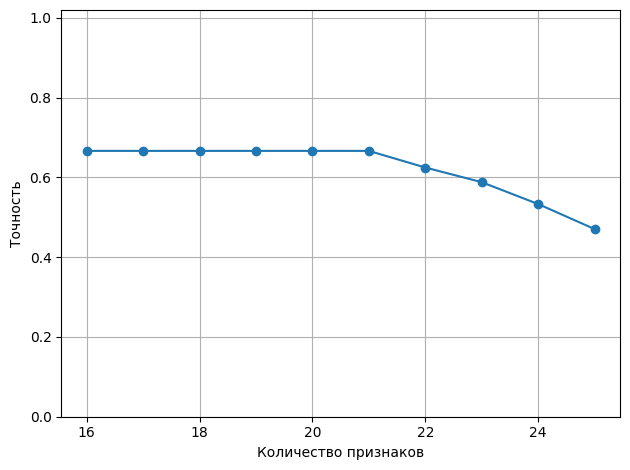

In [50]:
sbs_lr = the_best_features(lr, k_features=16, scoring=f1_scorer_micro, X_train=X_train_pca, y_train=y_train)

In [51]:
X_train_pca_sbs, X_test_pca_sbs = select_index_features(sbs_lr, index=-6, X_train=X_train_pca, X_test=X_test_pca)

In [56]:
lr = OneVsRestClassifier(LogisticRegression(C = 0.1, max_iter= 1000, penalty = 'l2', solver = 'liblinear'))
lr = model_training(lr, X_train=X_train_pca_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.556
Fold 4: f1_macro = 0.333
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.222
Fold 11: f1_macro = 0.333
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.556
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.333
Fold 16: f1_macro = 0.556
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.311 (+/- 0.232)


In [57]:
data = {"Train": (X_train_pca_sbs, y_train),
        "Test": (X_test_pca_sbs, y_test)}

In [58]:
print(y_train.shape, y_test.shape)
print(y_train[:5])  # посмотреть примеры

(36, 3) (15, 3)
[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]


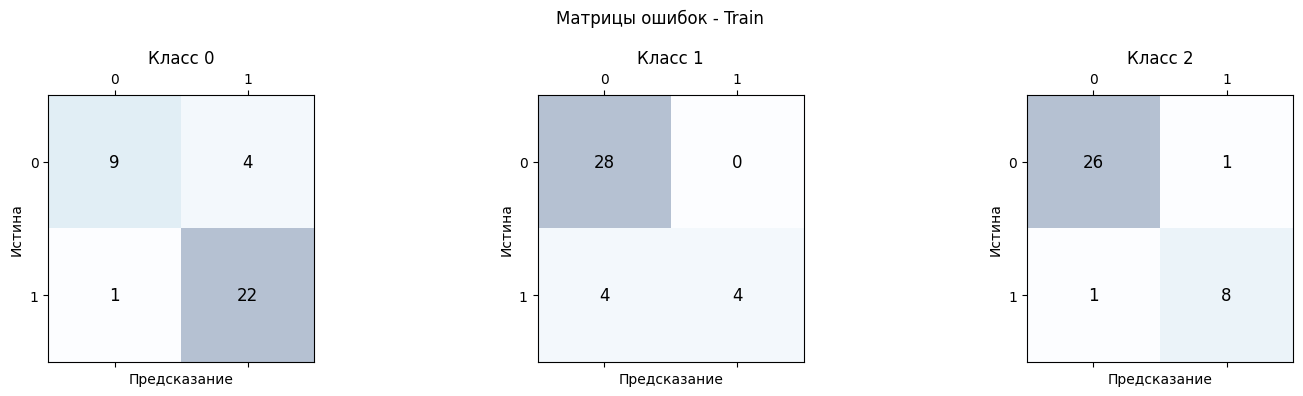

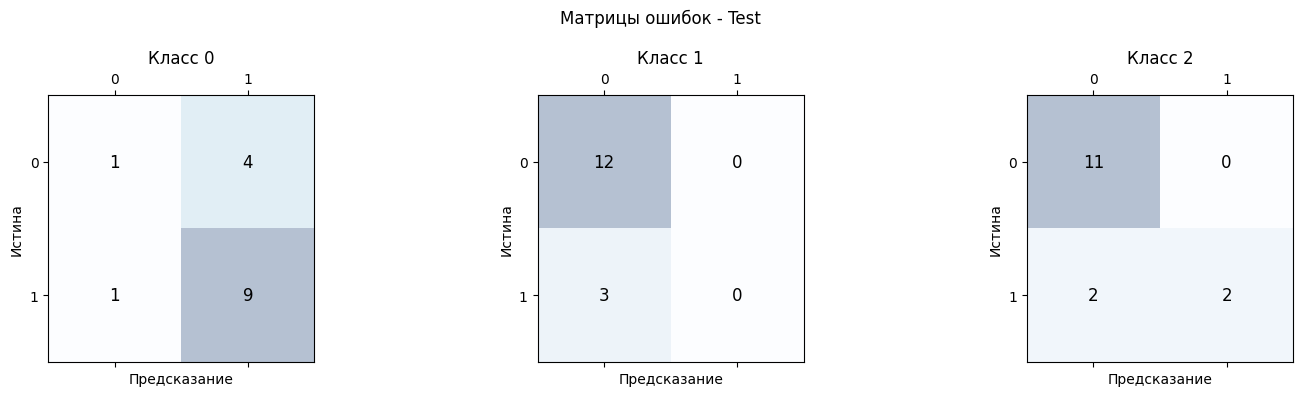

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.806 |                  0.887 |               0.912 |               0.85  |            0.782 |           0.85  |        0.818 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.6   |                  0.643 |               0.564 |               0.647 |            0.467 |           0.617 |        0.483 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

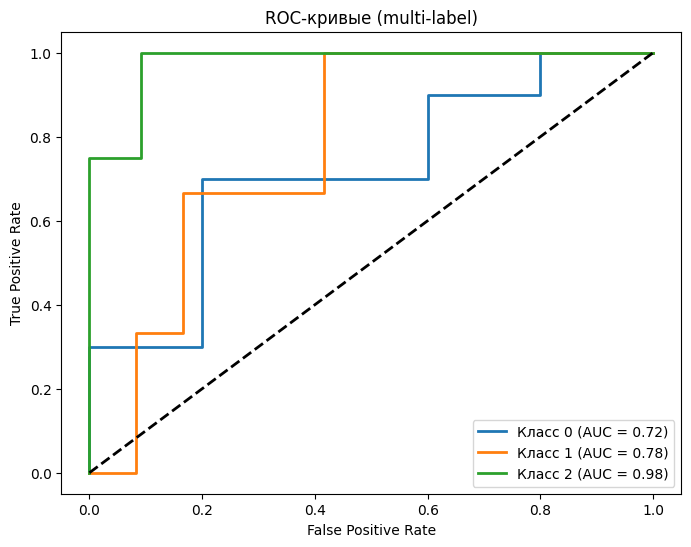

In [59]:
results = evaluate_model(lr, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
ROC_curve_multilabel(lr, X_test_pca_sbs, y_test, n_classes=3)

### Алгоритм k-ближайших соседей

In [60]:
knn =  OneVsRestClassifier(KNeighborsClassifier(metric='minkowski'))
param_grid_knn = {
    'estimator__n_neighbors': list(range(1, 7, 2)),
    'estimator__weights': ['uniform', 'distance'],
    'estimator__algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'estimator__p': [1, 2, 3], 
    'estimator__leaf_size': [10, 20, 30, 40, 50]
}
grid_search_for_model(knn, param_grid_knn, X_train_pca, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 270 candidates, totalling 540 fits
0.6
{'estimator__algorithm': 'auto', 'estimator__leaf_size': 10, 'estimator__n_neighbors': 1, 'estimator__p': 2, 'estimator__weights': 'uniform'}


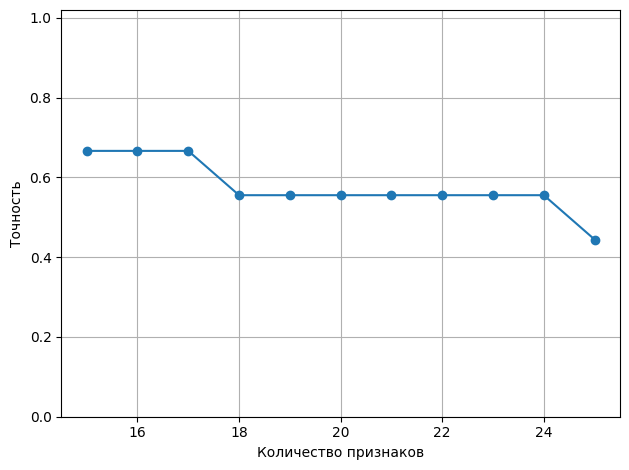

In [61]:
knn =  OneVsRestClassifier(KNeighborsClassifier(metric='minkowski', algorithm = 'auto', leaf_size = 10, n_neighbors = 1, p = 2, weights= 'uniform'))
sbs_knn = the_best_features(knn, k_features=15, scoring=f1_scorer_micro, X_train=X_train_pca, y_train=y_train)

In [62]:
X_train_pca_sbs, X_test_pca_sbs = select_index_features(sbs_knn, index=-1, X_train=X_train_pca, X_test=X_test_pca)

In [63]:
knn = OneVsRestClassifier(KNeighborsClassifier(metric='minkowski', algorithm = 'auto', leaf_size = 10, n_neighbors = 1, p = 2, weights= 'uniform'))
knn = model_training(knn, X_train=X_train_pca_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.222
Fold 3: f1_macro = 0.667
Fold 4: f1_macro = 0.333
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.222
Fold 11: f1_macro = 0.000
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.222
Fold 14: f1_macro = 0.222
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.333
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.333
Mean f1_macro: 0.267 (+/- 0.200)


In [64]:
data = {"Train": (X_train_pca_sbs, y_train),
        "Test": (X_test_pca_sbs, y_test)}

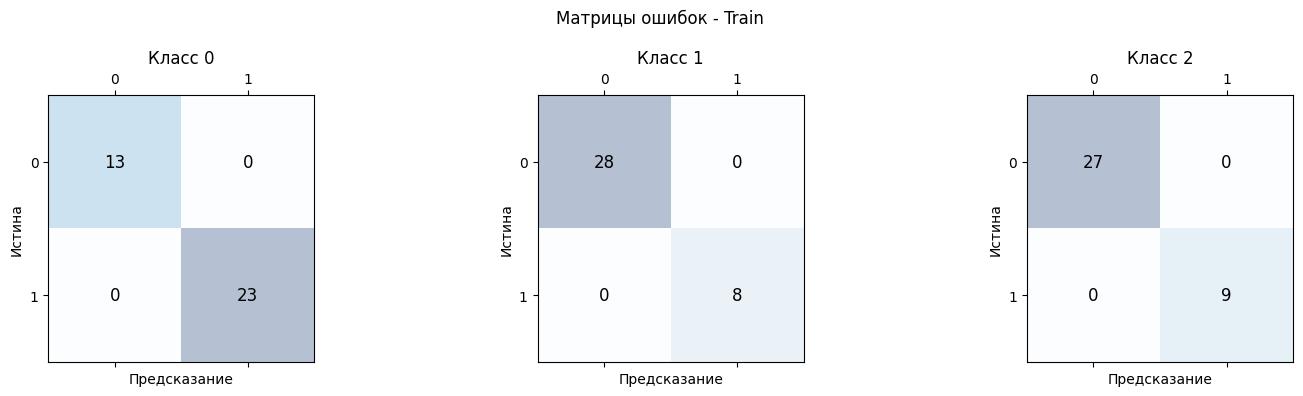

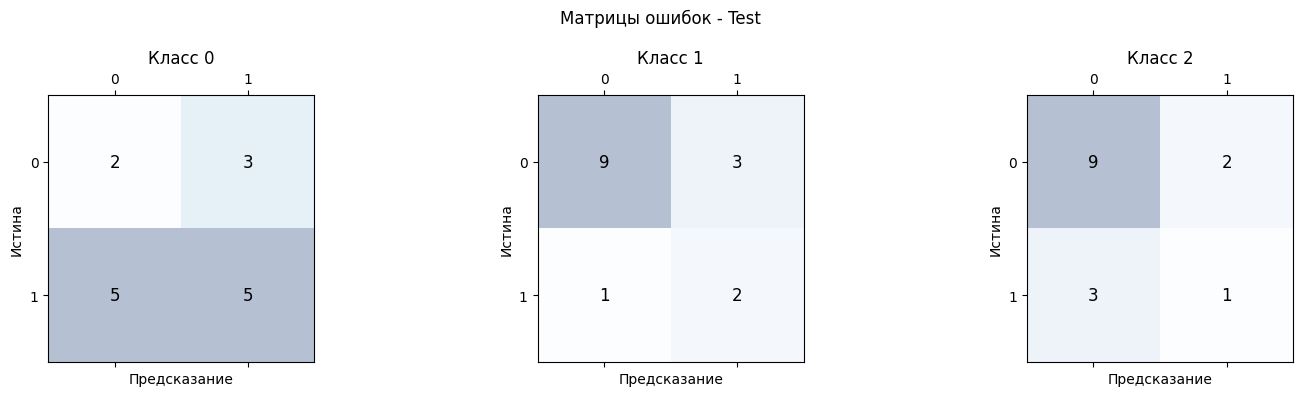

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |        1   |                  1     |               1     |               1     |            1     |           1     |        1     |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |        0.4 |                  0.517 |               0.453 |               0.471 |            0.472 |           0.482 |        0.447 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

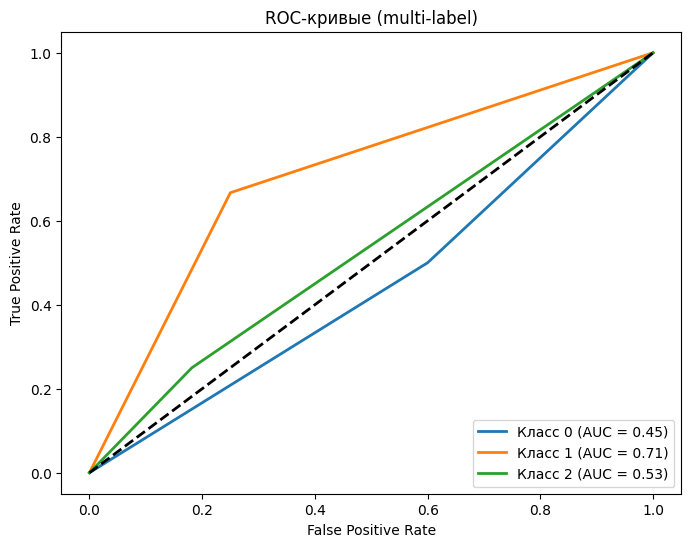

In [65]:
results = evaluate_model(knn, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
ROC_curve_multilabel(knn, X_test_pca_sbs, y_test, n_classes=3)

### SVM

In [66]:
svc =OneVsRestClassifier(SVC(random_state=1))
param_grid_svc = [
    {
        'estimator__kernel': ['linear'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'estimator__kernel': ['rbf'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'estimator__kernel': ['poly'],
        'estimator__C': [0.1, 1, 10],
        'estimator__gamma': ['scale', 'auto'],
        'estimator__degree': [2, 3],
        'estimator__coef0': [0, 1, 2]  
    }
]
grid_search_for_model(svc, param_grid_svc, X_train_pca, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 92 candidates, totalling 184 fits
0.575
{'estimator__C': 1, 'estimator__kernel': 'linear'}


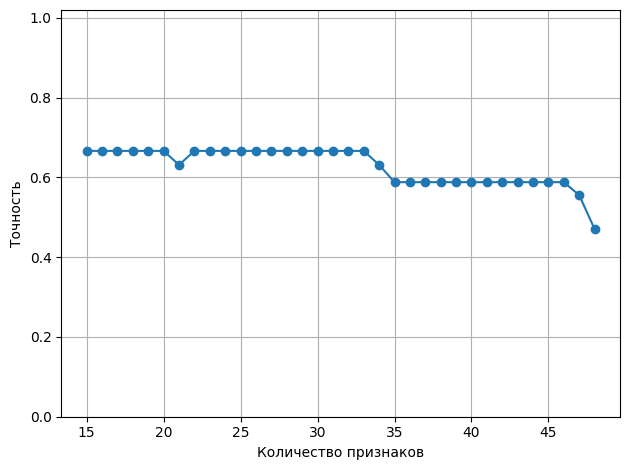

In [67]:
sbs_svc = the_best_features(OneVsRestClassifier(SVC(kernel='linear', C=1)), k_features=15, 
                            scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [71]:
X_train_sbs, X_test_sbs = select_index_features(sbs_svc, index=0, X_train=X_train, X_test=X_test)

In [72]:
svc = OneVsRestClassifier(SVC(random_state=1, kernel='linear', C=1, probability=True))
svc = model_training(svc, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.222
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.556
Fold 11: f1_macro = 0.667
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.333
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.289 (+/- 0.234)


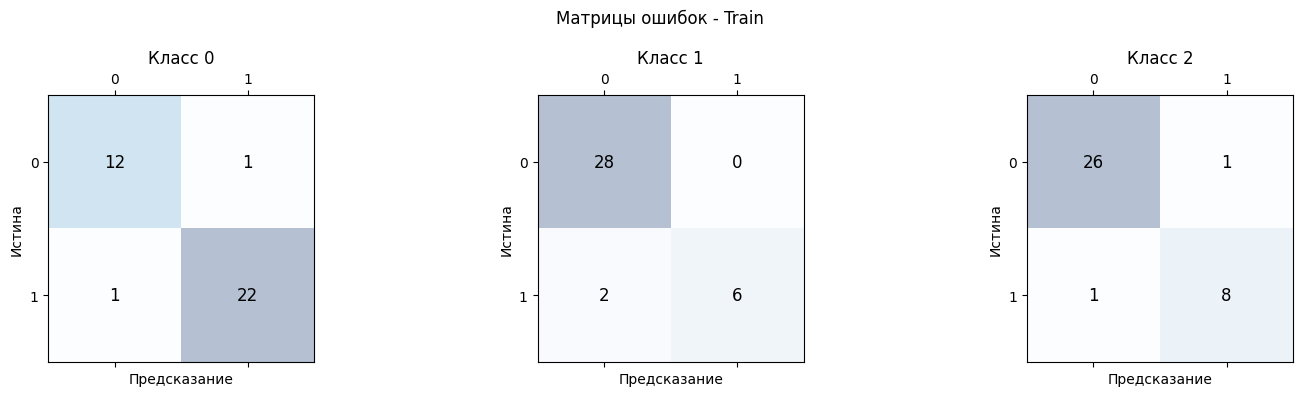

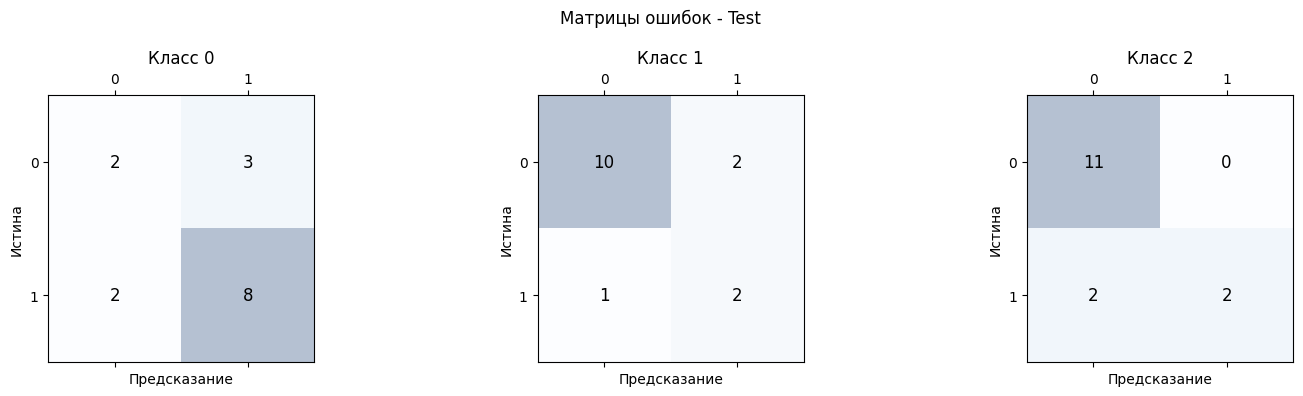

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.889 |                  0.95  |               0.948 |               0.9   |            0.865 |           0.921 |        0.901 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.533 |                  0.751 |               0.742 |               0.706 |            0.656 |           0.706 |        0.667 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

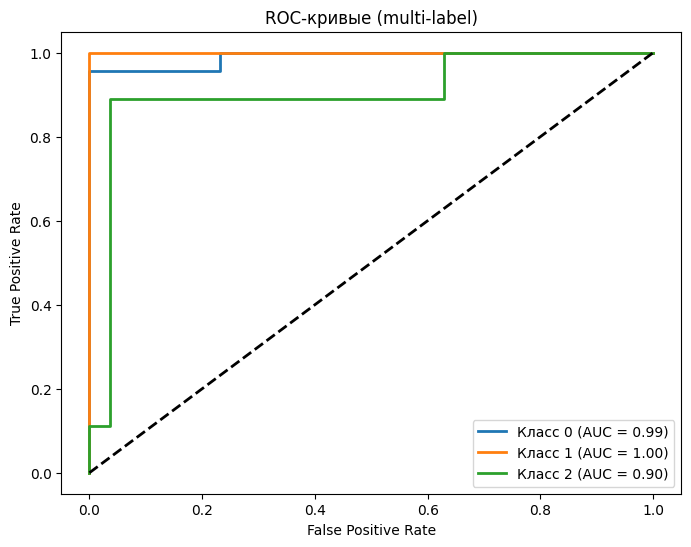

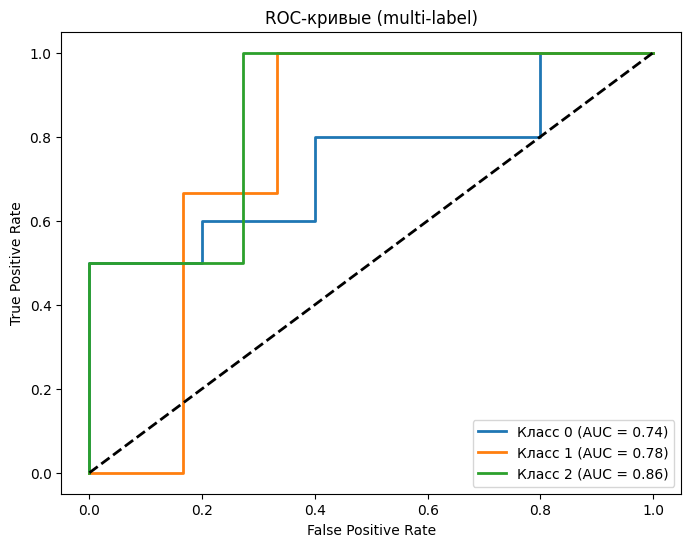

In [73]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(svc, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
ROC_curve_multilabel(svc, X_train_sbs, y_train, n_classes=3)
ROC_curve_multilabel(svc, X_test_sbs, y_test, n_classes=3)

In [80]:
index = 0
selected_features = list(sbs_svc.subsets_[index])
joblib.dump(selected_features, 'multi_selected_features_kas_sbs_svc_final.pkl')
joblib.dump(svc, 'svc_model_kas_sbs_multi_final.pkl')
joblib.dump(preprocessor, 'preprocessor_kas_sbs_multi_final.pkl')
metadata = {
    'model_type': type(svc).__name__,
    'params': {k: str(v) for k, v in svc.get_params().items()},
    'train_score': svc.score(X_train_sbs, y_train),
    'test_score': svc.score(X_test_sbs, y_test)
}
with open('metadata_kas_svc_sbs_multi.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### Random Forest

In [52]:
forest = OneVsRestClassifier(RandomForestClassifier(random_state=1, n_jobs=-1))
param_grid_forest = {
    'estimator__n_estimators': [50, 100, 150], 
    'estimator__max_depth': [None, 5, 10, 15], 
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2'],
    'estimator__class_weight': ['balanced', None],
    'estimator__bootstrap': [True, False] 
}
grid_search_for_model(forest, param_grid_forest, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 864 candidates, totalling 1728 fits
0.725
{'estimator__bootstrap': False, 'estimator__class_weight': 'balanced', 'estimator__max_depth': None, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 4, 'estimator__min_samples_split': 10, 'estimator__n_estimators': 150}


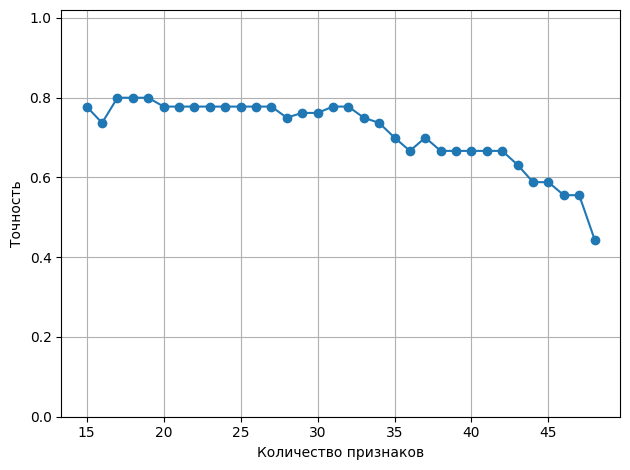

In [53]:
forest = OneVsRestClassifier(RandomForestClassifier(random_state=1, n_estimators= 150,class_weight = 'balanced',
                                                    max_features='sqrt', min_samples_leaf=4, min_samples_split=10,
                                                    bootstrap=False, max_depth=None, n_jobs=-1))
sbs_forest = the_best_features(forest, k_features=15, 
                            scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [54]:
X_train_sbs, X_test_sbs = select_index_features(sbs_forest, index=3, X_train=X_train, X_test=X_test)

In [55]:
forest = model_training(forest, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.000
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.556
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.333
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.222
Fold 10: f1_macro = 0.556
Fold 11: f1_macro = 0.667
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.556
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.333
Fold 16: f1_macro = 0.444
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.350 (+/- 0.234)


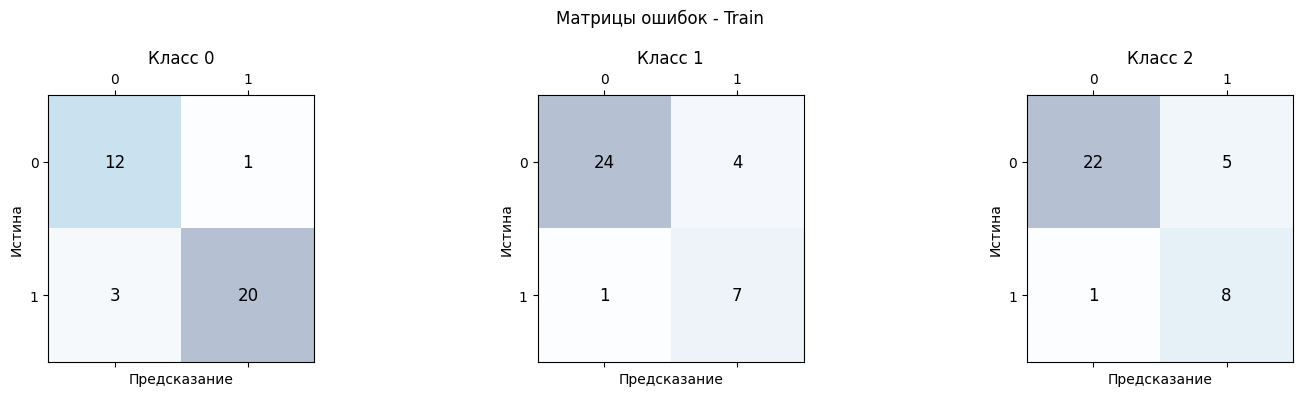

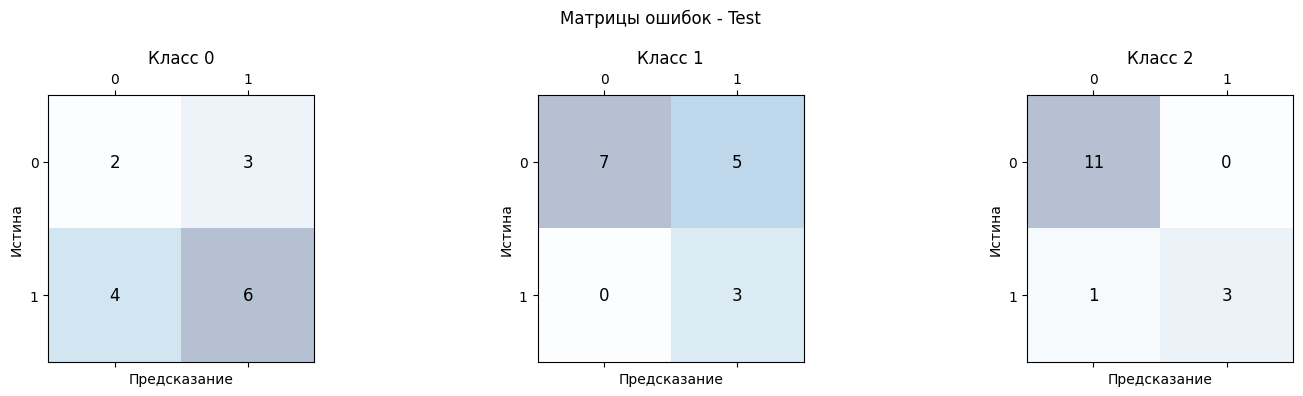

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.694 |                  0.813 |               0.735 |               0.875 |            0.878 |           0.834 |        0.791 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.467 |                  0.694 |               0.681 |               0.706 |            0.783 |           0.669 |        0.678 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

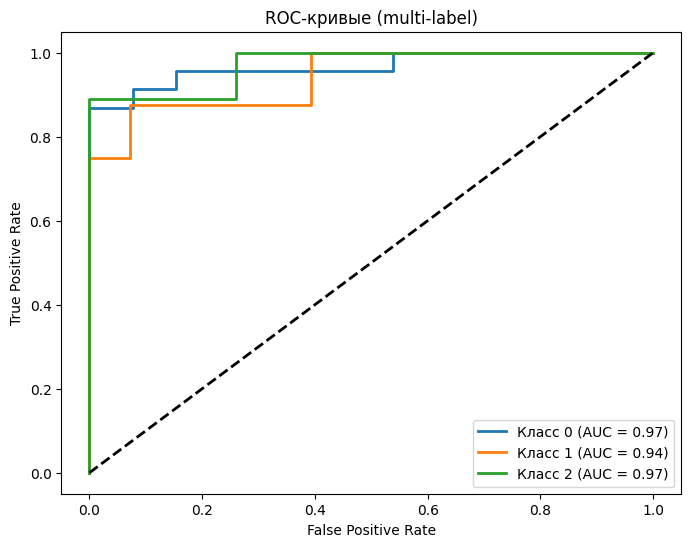

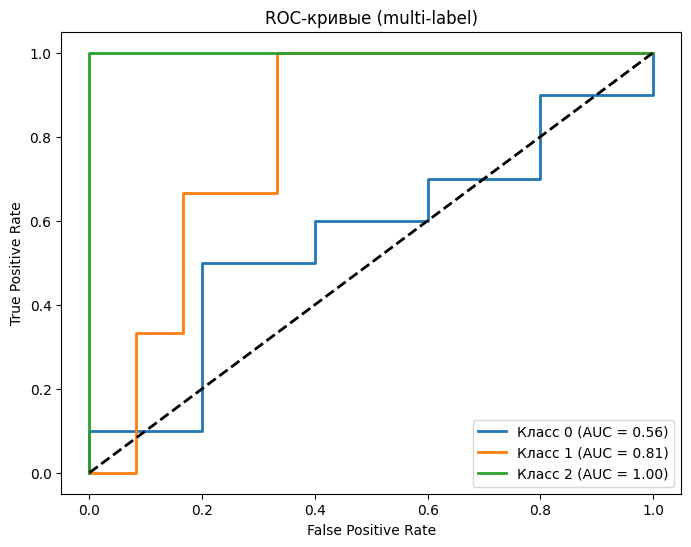

In [56]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(forest, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
ROC_curve_multilabel(forest, X_train_sbs, y_train, n_classes=3)
ROC_curve_multilabel(forest, X_test_sbs, y_test, n_classes=3)

In [62]:
index = 3
selected_features = list(sbs_forest.subsets_[index])
joblib.dump(selected_features, 'multi_selected_features_kas_sbs_forest_final.pkl')
joblib.dump(forest, 'forest_model_kas_sbs_multi_final.pkl')
metadata = {
    'model_type': type(forest).__name__,
    'params': {k: str(v) for k, v in forest.get_params().items()},
    'train_score': forest.score(X_train_sbs, y_train),
    'test_score': forest.score(X_test_sbs, y_test)
}
with open('metadata_kas_forest_sbs_multi.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### AdaBoost

In [351]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=3)
ada  = OneVsRestClassifier(AdaBoostClassifier(estimator=tree, random_state=1))
param_grid_ada = {
    'estimator__n_estimators': [25, 50, 100, 150, 200, 250],
    'estimator__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 1.0],
    'estimator__estimator__max_depth': [1, 2, 3, 4, 5]
}

grid_search_for_model(ada, param_grid_ada, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 126 candidates, totalling 252 fits
0.625
{'estimator__estimator__max_depth': 3, 'estimator__learning_rate': 0.01, 'estimator__n_estimators': 50}


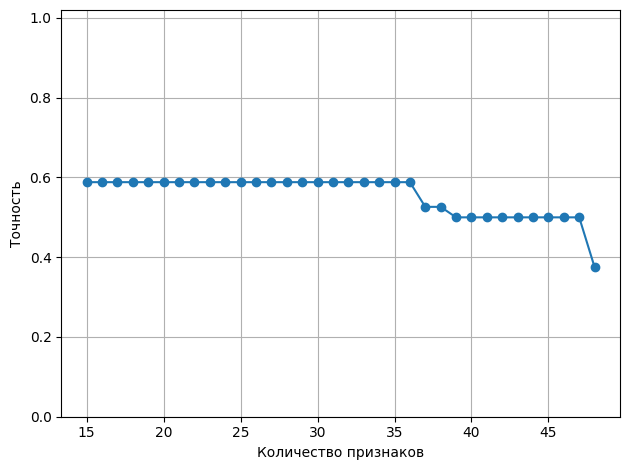

In [352]:
ada = OneVsRestClassifier(AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=3), 
                         n_estimators=50, learning_rate=0.01, random_state=1))
sbs_ada = the_best_features(ada, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [353]:
X_train_sbs, X_test_sbs = select_index_features(sbs_ada, index=4, X_train=X_train, X_test=X_test)

In [354]:
ada = model_training(ada, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.000
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.444
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.333
Fold 8: f1_macro = 0.333
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.444
Fold 11: f1_macro = 0.222
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.333
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.333
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.333
Fold 19: f1_macro = 0.000
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.222 (+/- 0.189)


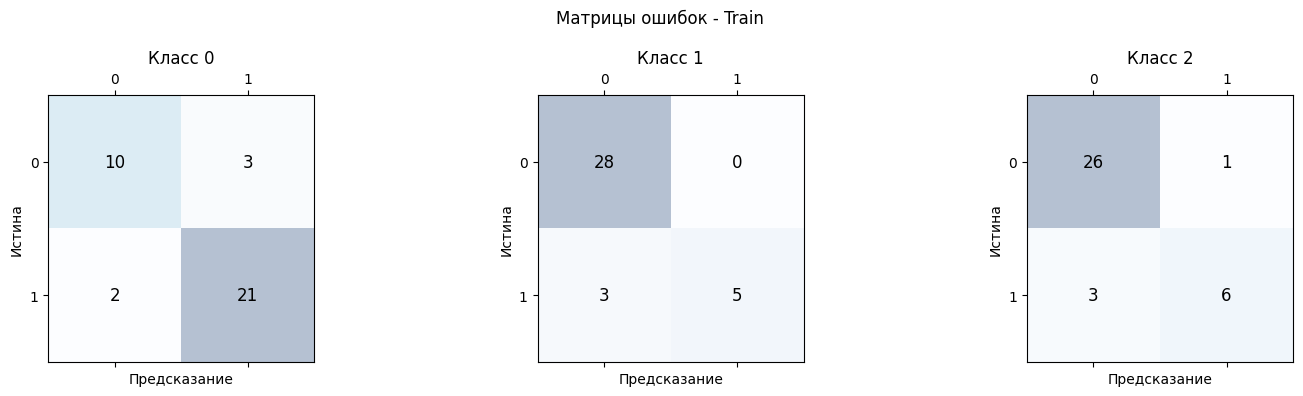

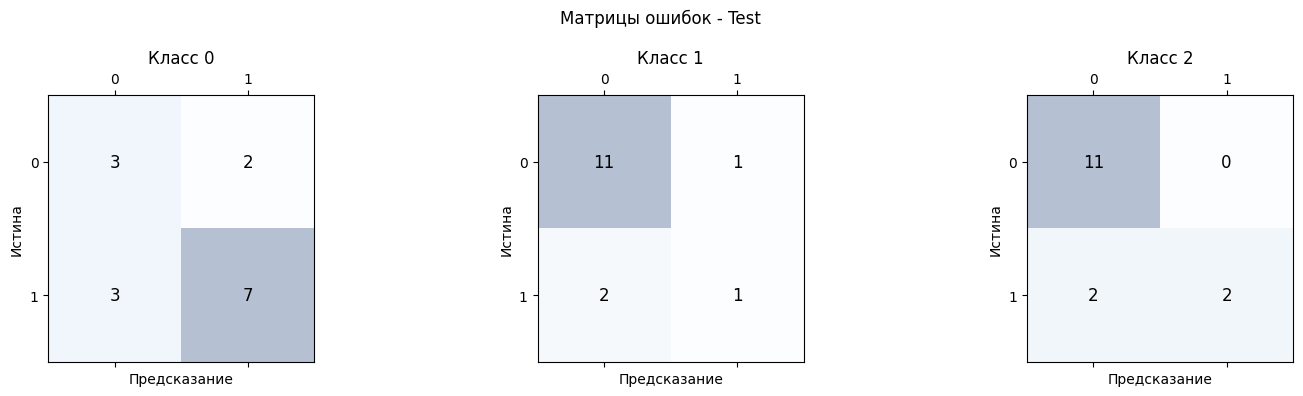

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.75  |                  0.896 |               0.911 |               0.8   |            0.735 |           0.836 |        0.804 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.467 |                  0.781 |               0.759 |               0.588 |            0.511 |           0.661 |        0.601 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

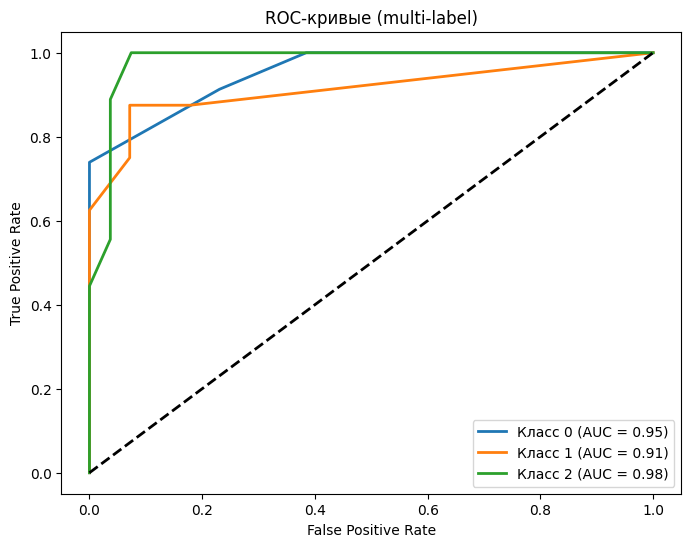

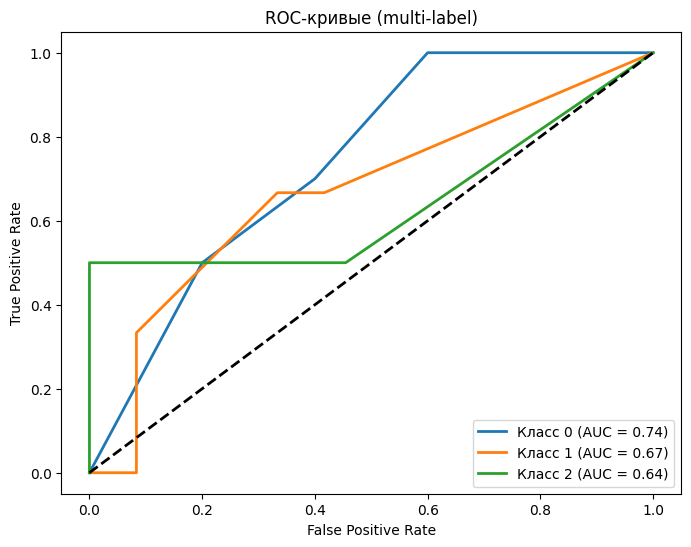

In [356]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(ada, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
ROC_curve_multilabel(ada, X_train_sbs, y_train, n_classes=3)
ROC_curve_multilabel(ada, X_test_sbs, y_test, n_classes=3)

### XGBoost

In [363]:
param_grid_xgb = {
    'estimator__n_estimators': [100, 150, 200, 300],
    'estimator__max_depth': [3, 4, 5],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__subsample': [0.6, 0.8, 1.0],
    'estimator__colsample_bytree': [0.6, 0.8, 1.0],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__reg_alpha': [0, 0.1, 1],
    'estimator__reg_lambda': [1, 1.5, 2]
}
xgbm =  OneVsRestClassifier(xgb.XGBClassifier(random_state=1))
grid_search_for_model(xgbm, param_grid_xgb, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 11664 candidates, totalling 23328 fits
0.625
{'estimator__colsample_bytree': 0.6, 'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__min_child_weight': 1, 'estimator__n_estimators': 150, 'estimator__reg_alpha': 0, 'estimator__reg_lambda': 1.5, 'estimator__subsample': 1.0}


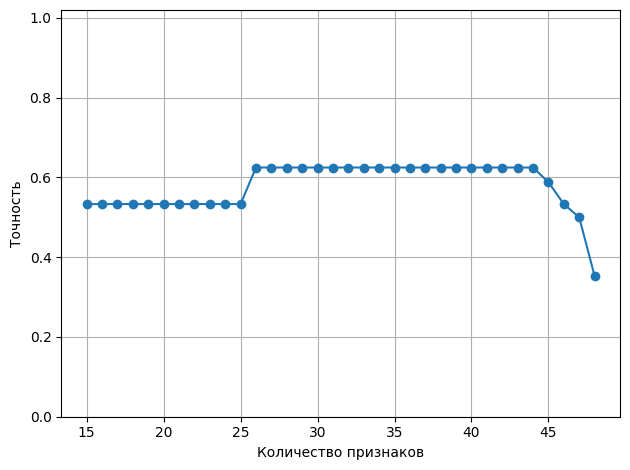

In [368]:
xgbm = OneVsRestClassifier(xgb.XGBClassifier(n_estimators=150, min_child_weight=1, max_depth=3, learning_rate=0.05, 
                                             colsample_bytree=0.6, reg_alpha=0,  reg_lambda=1.5, subsample=1.0, random_state=2))
sbs_xgbm = the_best_features(xgbm, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [369]:
X_train_sbs, X_test_sbs = select_index_features(sbs_xgbm, index=12, X_train=X_train, X_test=X_test)

In [370]:
xgbm = model_training(xgbm, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.556
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.222
Fold 10: f1_macro = 0.222
Fold 11: f1_macro = 0.222
Fold 12: f1_macro = 0.556
Fold 13: f1_macro = 0.222
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.267 (+/- 0.200)


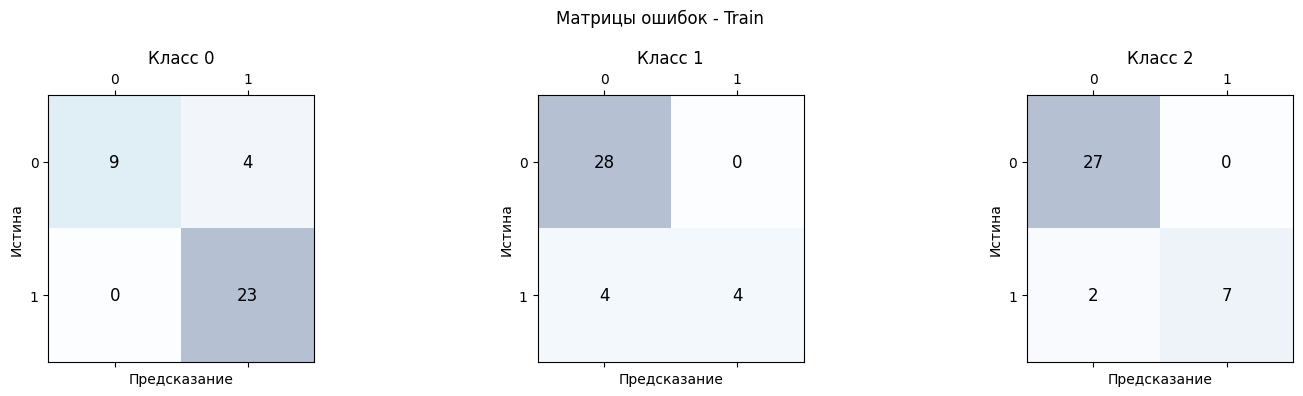

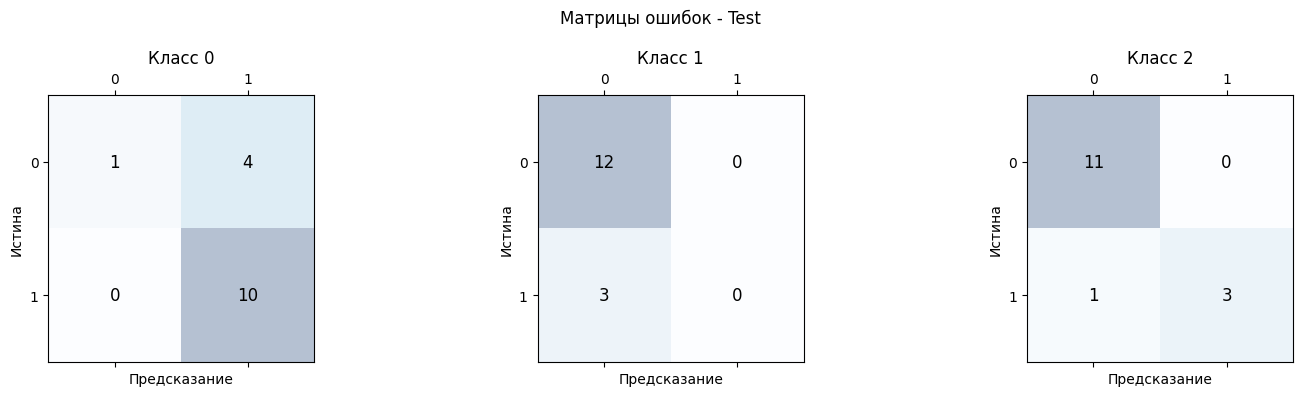

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.806 |                  0.915 |               0.951 |               0.85  |            0.759 |           0.859 |        0.821 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.733 |                  0.655 |               0.571 |               0.765 |            0.583 |           0.692 |        0.563 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

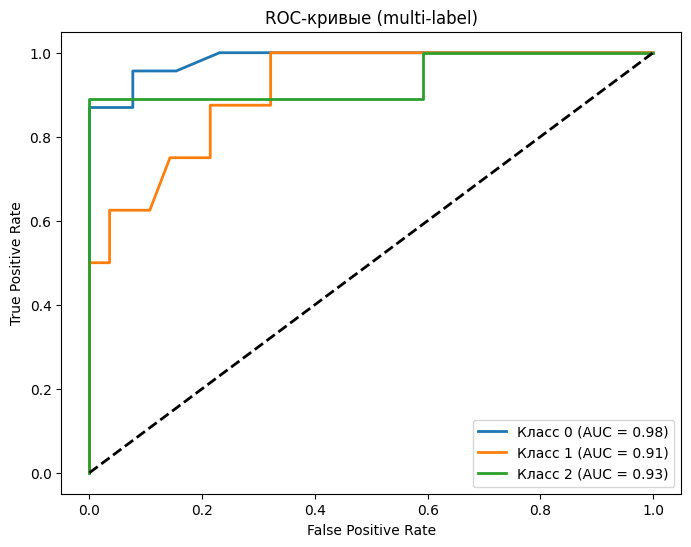

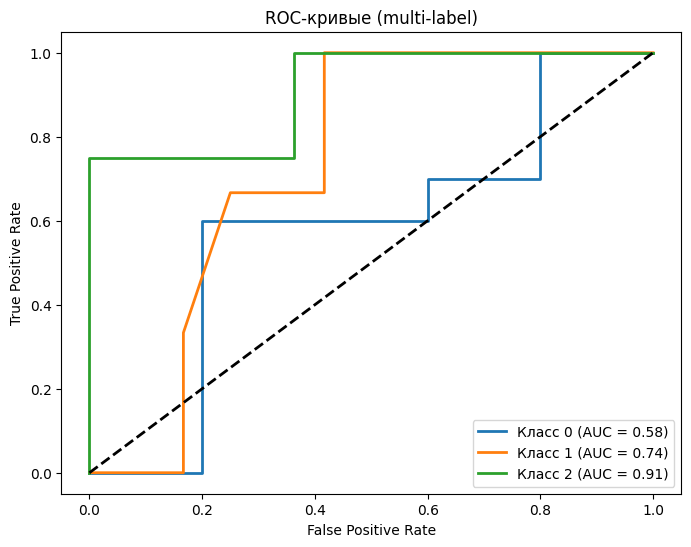

In [372]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(xgbm, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(xgbm, X_train_sbs, y_train, n_classes=3)
plot_roc_curve_multilabel(xgbm, X_test_sbs, y_test, n_classes=3)

### MLP

In [127]:
X_val, y_val, X_test, y_test = iterative_train_test_split(
   X_test_pca, y_test, test_size=0.5
)

In [73]:
param_grid_net = {
    'batch_size': [16, 32],
    'epochs': [30],
    'learning_rate': [0.001],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'elu'],
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'dropout_rate': [0.2],
    'use_batch_norm': [True],
    'l1_reg': [0.001],
    'l2_reg': [0.001]
}

best_score, best_params, all_results = manual_keras_grid_search(
    X_train_pca, y_train, param_grid_net, cv=5
)

Всего комбинаций: 24

Комбинация 1/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer': 'adam', 'use_batch_norm': True}
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
  Fold 1: recall = 0.2222
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
  Fold 2: recall = 0.7143
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
  Fold 3: recall = 0.5000
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
  Fold 4: recall = 0.8750
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
  Fold 5: recall = 0.3750
  Средний recall: 0.5373

Комбинация 2/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer'

In [158]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_pca.shape[1], )))

model.add(layers.Dense(32, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.01)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(16, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.01)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(8, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.01)))
model.add(layers.BatchNormalization())


model.add(layers.Dense(3, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_pca, y_train, epochs=20, batch_size=10, validation_data=(X_val, y_val))

Epoch 1/20
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.6000 - loss: 1.3389 - precision: 0.4286 - recall: 0.5455
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.4078 - loss: 1.4216 - precision: 0.3283 - recall: 0.4218 - val_accuracy: 0.7143 - val_loss: 1.2246 - val_precision: 0.5000 - val_recall: 0.6250
Epoch 2/20
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5000 - loss: 1.3470 - precision: 0.4286 - recall: 0.5455
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3867 - loss: 1.3720 - precision: 0.4025 - recall: 0.5144 - val_accuracy: 0.7143 - val_loss: 1.2172 - val_precision: 0.5556 - val_recall: 0.6250
Epoch 3/20
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2000 - loss: 1.4881 - precision: 0.3571 - recall: 0.3846
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3456 - loss: 1.4262 - precision: 0.3465 - recall: 0.4344 - val_accuracy: 0.7143 - val_loss: 1.2114 - val_precision: 0.5556 - val_recall: 0.6250
Epoch 4/20
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

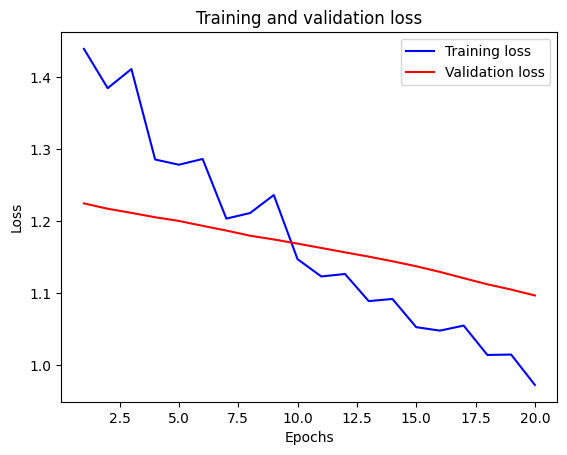

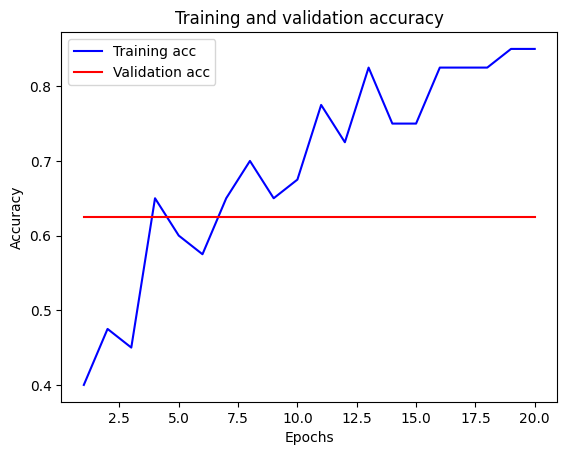

<Figure size 640x480 with 0 Axes>

In [159]:
history_dict = history.history
epochs = range(1, 21)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.clf()

In [160]:
data = {
            "Train": (X_train_pca, y_train),
            "Validation": (X_val, y_val),
            "Test": (X_test, y_test)
        }

2
21/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
22/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


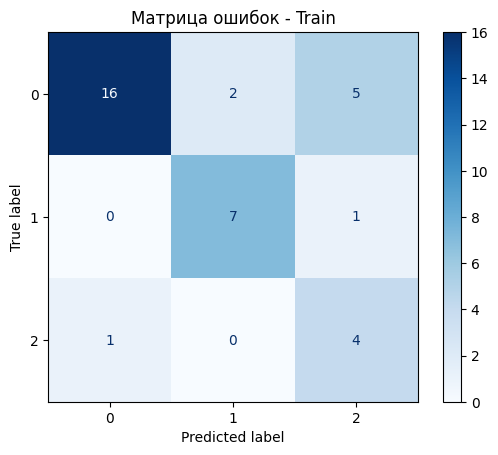

1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


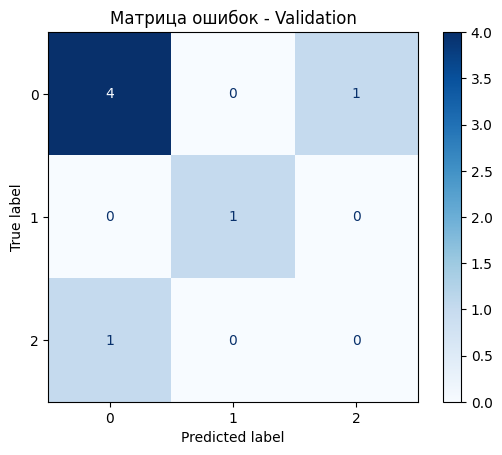

1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


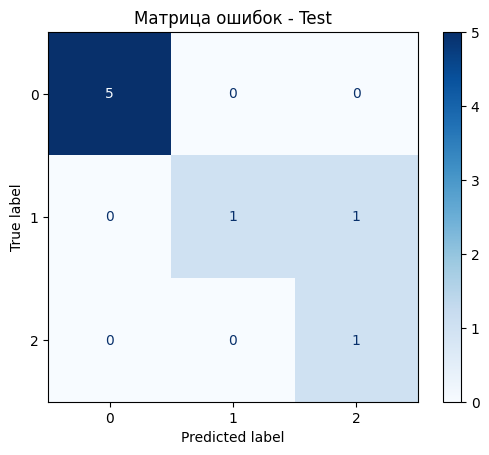

+------------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+------------------+---------------+
|  Dataset   |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |   Mcc (weighted) |   Mcc (macro) |
+============+============+========================+=====================+=====================+==================+=================+==============+==================+===============+
|   Train    |      0.75  |                  0.83  |               0.706 |               0.75  |            0.79  |           0.768 |        0.719 |                0 |             0 |
+------------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+------------------+---------------+
| Validation |      0.714 |                  0.714 |               0.6   |      

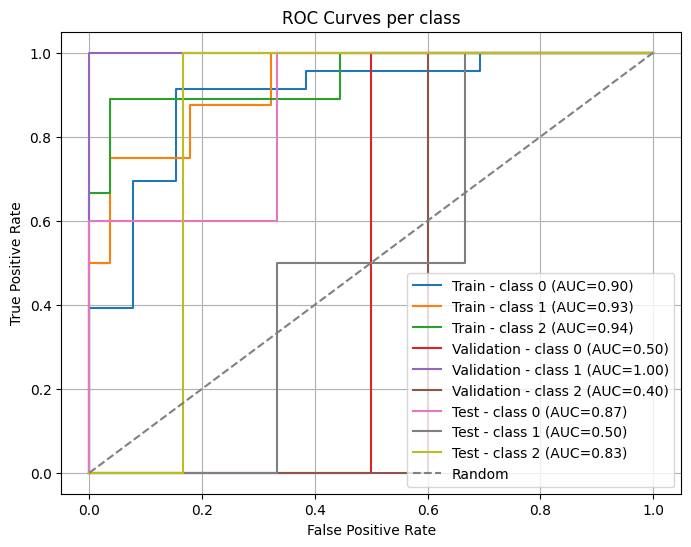

In [161]:
results = evaluate_model_for_keras(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['weighted', 'macro'])
ROC_curve_for_keras(data, model)

In [41]:
model.save('model_Kas_classification_recall_best.keras')

## Уменьшение размерности с помощью алгоритма отбора признаков и обучение различных типов моделей

In [42]:
X_train, y_train, X_test, y_test = iterative_train_test_split(
    X_np, y_np, test_size=0.3)

In [169]:
X_train

array([[ 0,  1,  0, ...,  0,  1,  0],
       [ 1,  0,  0, ...,  0,  1,  0],
       [ 0,  1,  0, ...,  1,  0, -2],
       ...,
       [ 1,  0,  0, ...,  1,  0,  0],
       [ 0,  1,  0, ...,  0,  0,  0],
       [ 0,  1,  0, ...,  0,  0,  0]])

### Логистическая регрессия

In [173]:
lr = OneVsRestClassifier(LogisticRegression(random_state=1))
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_grid_lr = [{'estimator__C': param_range, 'estimator__solver': ['lbfgs'], 
                  'estimator__penalty': ['l2'], 'estimator__max_iter': [1000, 2000, 5000, 1000] }, 
             {'estimator__C': param_range, 'estimator__solver': ['liblinear'], 
              'estimator__penalty': ['l2', 'l1'], 'estimator__max_iter': [100, 200, 5000, 1000] }, 
             {'estimator__C': param_range, 'estimator__solver': ['newton-cg'], 'estimator__penalty': ['l2']},
             {'estimator__C': param_range, 'estimator__solver': ['newton-cholesky'], 
              'estimator__penalty': ['l2'], 'estimator__max_iter': [100, 200, 500, 1000] },
             {'estimator__C': param_range, 'estimator__solver': ['sag'], 
              'estimator__penalty': ['l2'], 'estimator__max_iter': [5000, 10000] },
             {'estimator__C': param_range, 'estimator__solver': ['saga'], 'estimator__penalty': ['elasticnet'], 
              'estimator__max_iter': [5000, 10000], 'estimator__l1_ratio': [0.1, 0.2, 0.5, 0.9]},
            {'estimator__C': param_range, 'estimator__solver': ['saga'], 'estimator__penalty': ['l1', 'l2'], 'estimator__max_iter': [5000, 10000]}
             ]
grid_search_for_model(lr, param_grid_lr, X_train, y_train, cv=2, scoring='recall_weighted') 

Fitting 2 folds for each of 186 candidates, totalling 372 fits
0.625
{'estimator__C': 10.0, 'estimator__max_iter': 1000, 'estimator__penalty': 'l2', 'estimator__solver': 'lbfgs'}


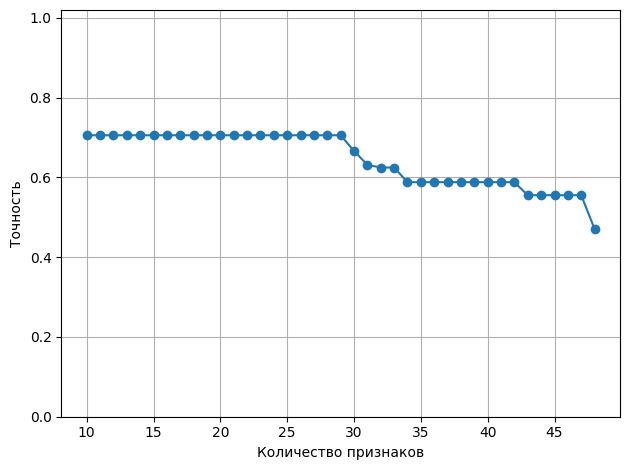

In [174]:
lr = OneVsRestClassifier(LogisticRegression(random_state=1, C=10.0, max_iter=100, penalty='l2', solver='lbfgs'))
sbs_lr = the_best_features(lr, k_features=10, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [176]:
X_train_sbs, X_test_sbs = select_index_features(sbs_lr, index=0, X_train=X_train, X_test=X_test)

In [178]:
lr = model_training(lr, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.444
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.556
Fold 11: f1_macro = 0.333
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.333
Fold 14: f1_macro = 0.222
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.294 (+/- 0.212)


In [179]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}

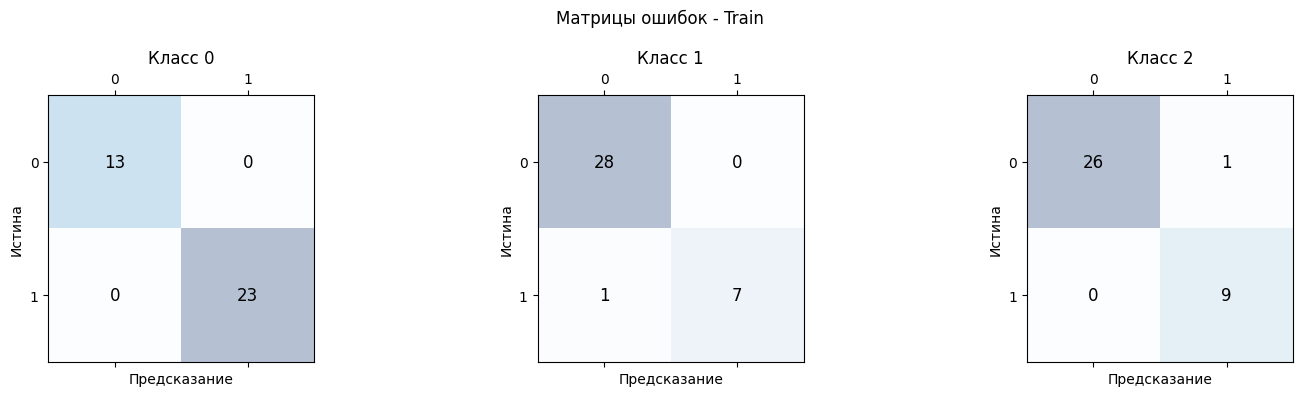

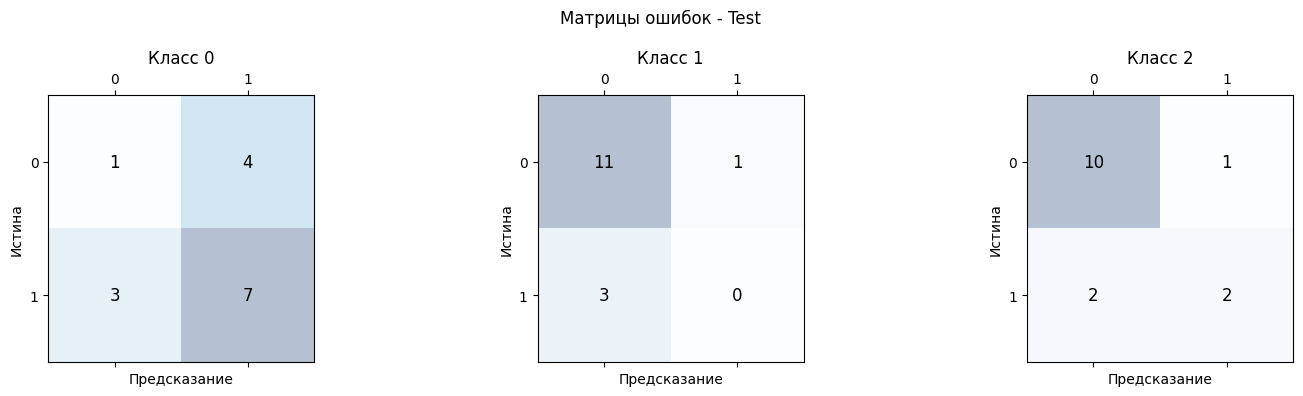

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.972 |                  0.978 |               0.967 |               0.975 |            0.958 |           0.975 |        0.96  |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.467 |                  0.531 |               0.434 |               0.529 |            0.4   |           0.527 |        0.413 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

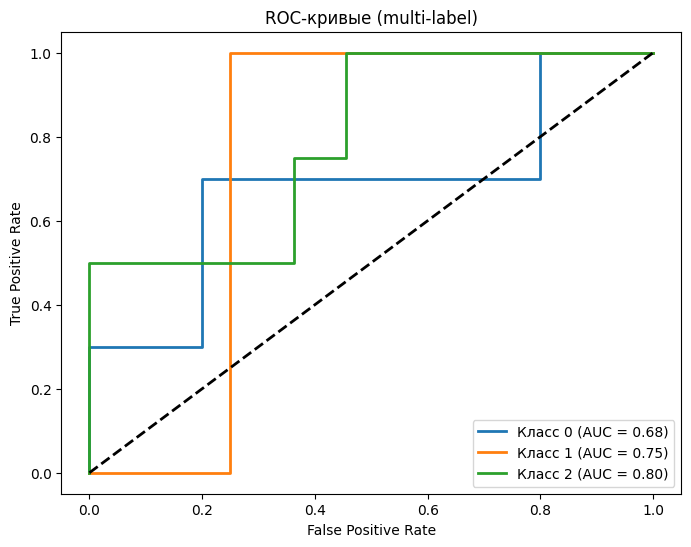

In [181]:
results = evaluate_model(lr, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(lr, X_test, y_test, n_classes=3)

### Алгоритм k-ближайших соседей

In [182]:
knn = OneVsRestClassifier(KNeighborsClassifier(metric='minkowski'))
param_grid_knn = {
    'estimator__n_neighbors': list(range(1, 7, 2)),
    'estimator__weights': ['uniform', 'distance'],
    'estimator__algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'estimator__p': [1, 2, 3], 
    'estimator__leaf_size': [10, 20, 30, 40, 50]
}
grid_search_for_model(knn, param_grid_knn, X_train_pca, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 270 candidates, totalling 540 fits
0.6
{'estimator__algorithm': 'auto', 'estimator__leaf_size': 10, 'estimator__n_neighbors': 1, 'estimator__p': 2, 'estimator__weights': 'uniform'}


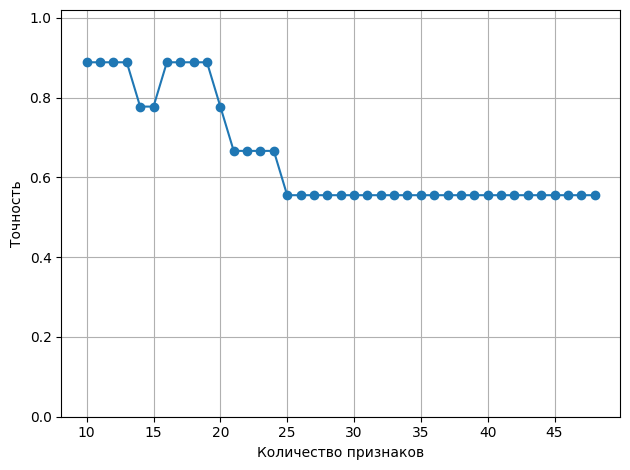

In [184]:
knn = OneVsRestClassifier(KNeighborsClassifier(metric='minkowski', algorithm = 'auto', 
                                               leaf_size = 10, n_neighbors = 1, p = 2, weights = 'uniform'))
sbs_knn = the_best_features(knn, k_features=10, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [187]:
X_train_sbs, X_test_sbs = select_index_features(sbs_knn, index=0, X_train=X_train, X_test=X_test)

In [189]:
knn = model_training(knn, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.222
Fold 3: f1_macro = 0.667
Fold 4: f1_macro = 0.333
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.222
Fold 11: f1_macro = 0.222
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.667
Fold 14: f1_macro = 0.333
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.667
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.333
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.311 (+/- 0.232)


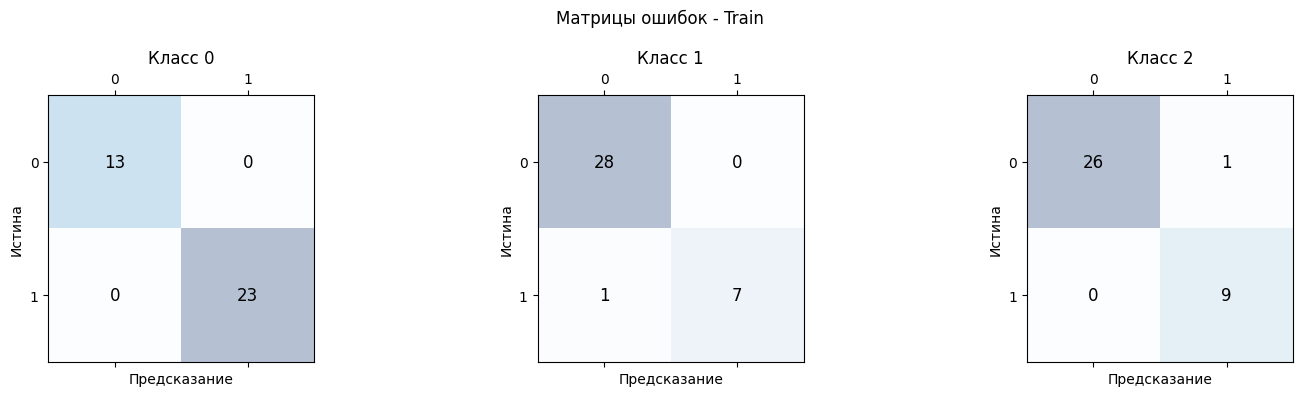

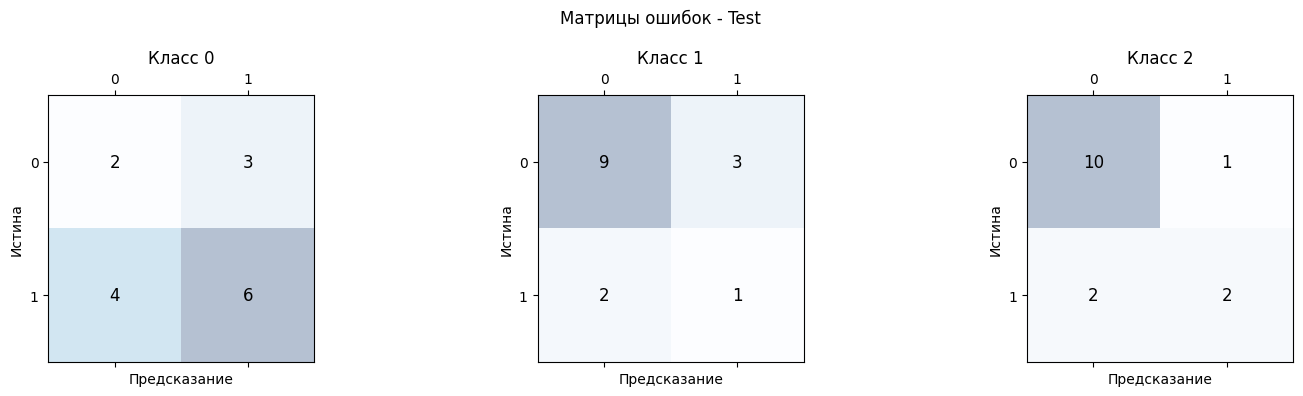

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.972 |                  0.978 |               0.967 |               0.975 |            0.958 |           0.975 |        0.96  |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.467 |                  0.593 |               0.528 |               0.529 |            0.478 |           0.556 |        0.496 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

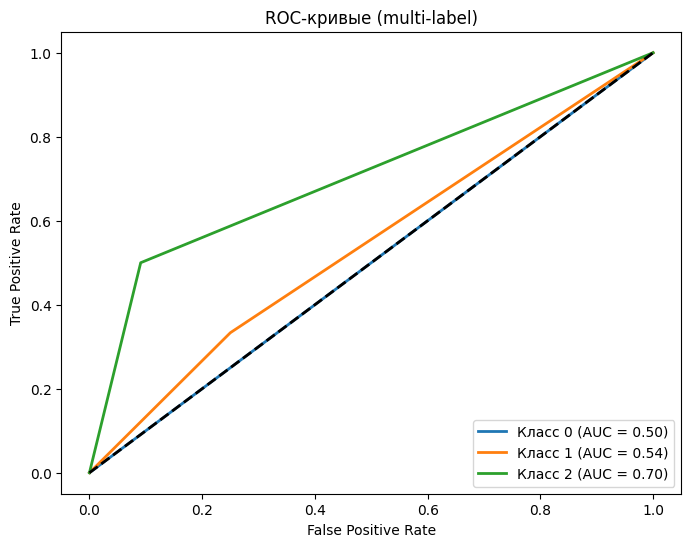

In [190]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(knn, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(knn, X_test_sbs, y_test, n_classes=3)

### SMV

In [191]:
svc = OneVsRestClassifier(SVC(random_state=1))
param_grid_svc = [
    {
        'estimator__kernel': ['linear'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'estimator__kernel': ['rbf'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'estimator__kernel': ['poly'],
        'estimator__C': [0.1, 1, 10],
        'estimator__gamma': ['scale', 'auto'],
        'estimator__degree': [2, 3],
        'estimator__coef0': [0, 1, 2]  
    }
]
grid_search_for_model(svc, param_grid_svc, X_train_pca, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 92 candidates, totalling 184 fits
0.575
{'estimator__C': 1, 'estimator__kernel': 'linear'}


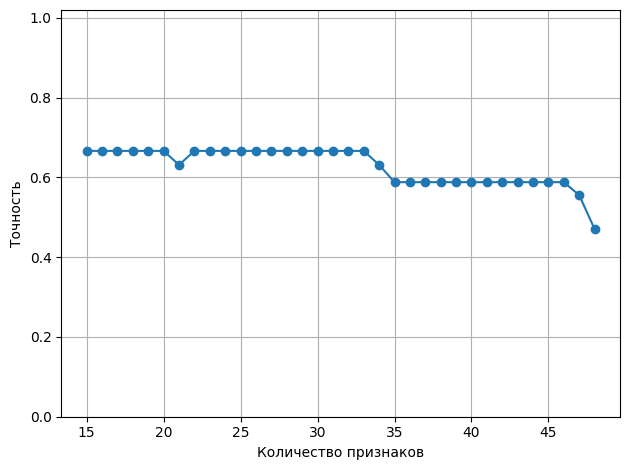

In [192]:
svc =  OneVsRestClassifier(SVC(kernel='linear', C=1, probability=True))
sbs_svc = the_best_features(svc, k_features=15, 
                            scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [195]:
X_train_sbs, X_test_sbs = select_index_features(sbs_svc, index=0, X_train=X_train, X_test=X_test)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.222
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 0.556
Fold 11: f1_macro = 0.667
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.333
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.289 (+/- 0.234)


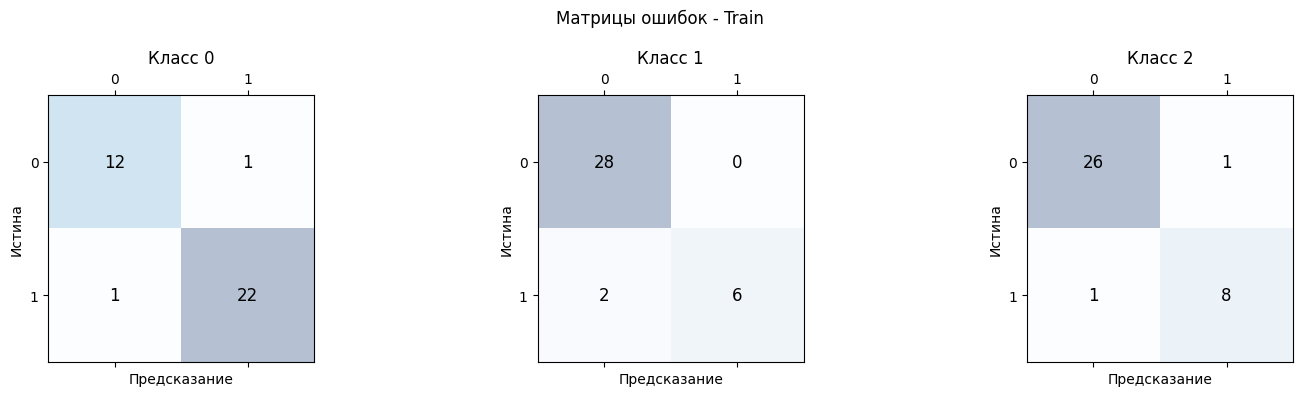

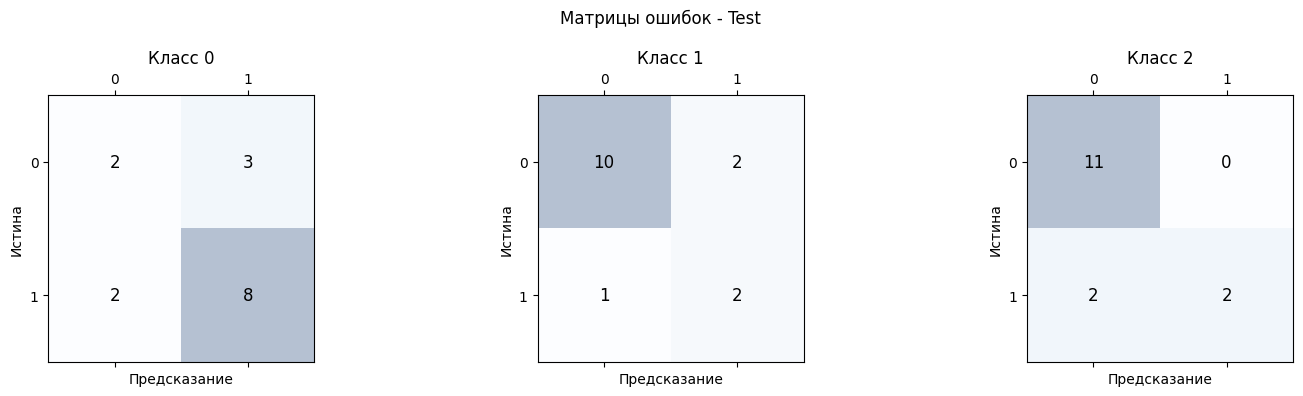

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.889 |                  0.95  |               0.948 |               0.9   |            0.865 |           0.921 |        0.901 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.533 |                  0.751 |               0.742 |               0.706 |            0.656 |           0.706 |        0.667 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

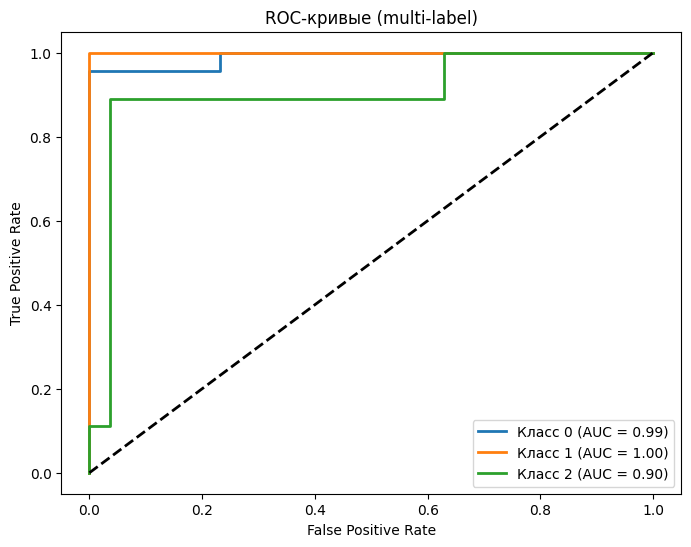

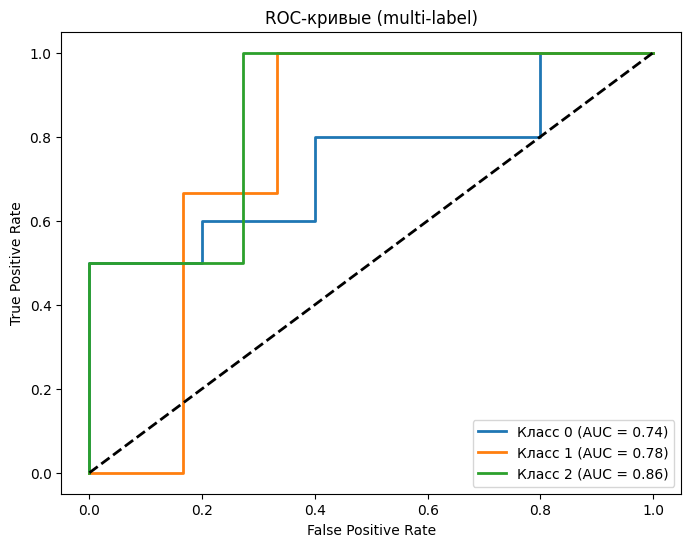

In [197]:
svc = model_training(svc, X_train=X_train_sbs, y_train=y_train, n_splits=20)
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(svc, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(svc, X_train_sbs, y_train, n_classes=3)
plot_roc_curve_multilabel(svc, X_test_sbs, y_test, n_classes=3)

In [198]:
import joblib

joblib.dump({
    'model': svc,
    'metadata': {
        'train_score': svc.score(X_train_sbs, y_train),
        'test_score': svc.score(X_test_sbs, y_test)
    }
}, 'model_and_metadata_kas_svc.pkl')

['model_and_metadata_kas_svc.pkl']

### Random Forest

In [199]:
forest = OneVsRestClassifier(RandomForestClassifier(random_state=1, n_jobs=-1))
param_grid_forest = {
    'estimator__n_estimators': [50, 100, 150], 
    'estimator__max_depth': [None, 5, 10, 15], 
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2'],
    'estimator__class_weight': ['balanced', None],
    'estimator__bootstrap': [True, False] 
}
grid_search_for_model(forest, param_grid_forest, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 864 candidates, totalling 1728 fits
0.725
{'estimator__bootstrap': False, 'estimator__class_weight': 'balanced', 'estimator__max_depth': None, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 4, 'estimator__min_samples_split': 10, 'estimator__n_estimators': 150}


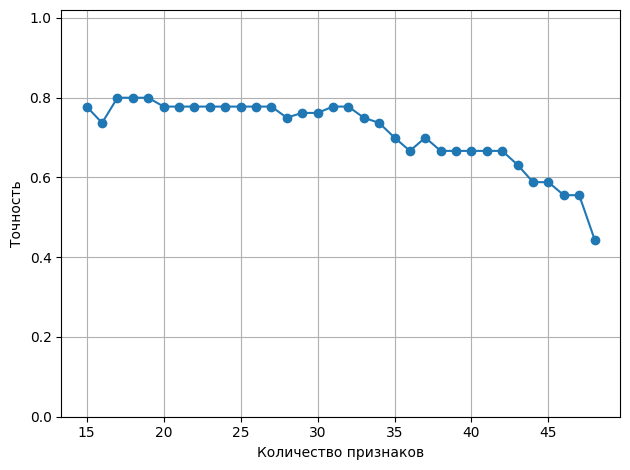

In [200]:
forest = OneVsRestClassifier(RandomForestClassifier(random_state=1, n_estimators= 150,class_weight = 'balanced',
                                                    max_features='sqrt', min_samples_leaf=4, min_samples_split=10,
                                                    bootstrap=False, max_depth=None, n_jobs=-1))
sbs_forest = the_best_features(forest, k_features=15, 
                            scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [201]:
X_train_sbs, X_test_sbs = select_index_features(sbs_forest, index=2, X_train=X_train, X_test=X_test)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.444
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.333
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.222
Fold 10: f1_macro = 0.556
Fold 11: f1_macro = 0.667
Fold 12: f1_macro = 0.667
Fold 13: f1_macro = 0.556
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.333
Fold 16: f1_macro = 0.444
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.356 (+/- 0.218)


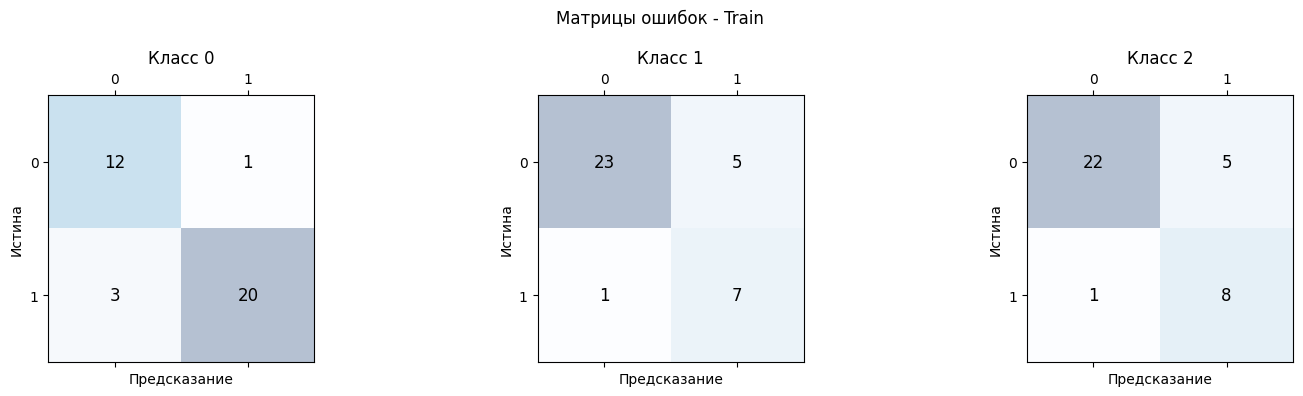

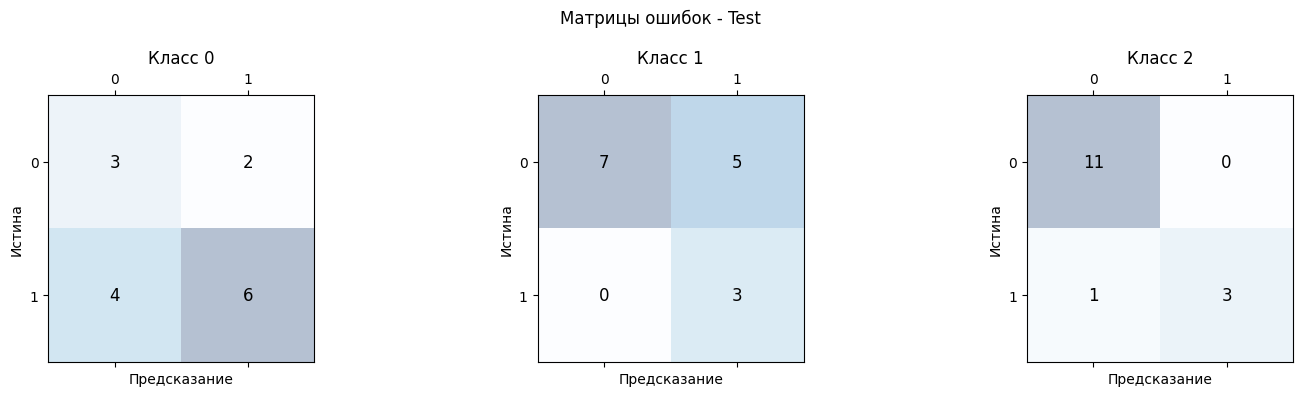

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.667 |                  0.803 |               0.717 |               0.875 |            0.878 |           0.826 |        0.779 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.533 |                  0.743 |               0.708 |               0.706 |            0.783 |           0.69  |        0.69  |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

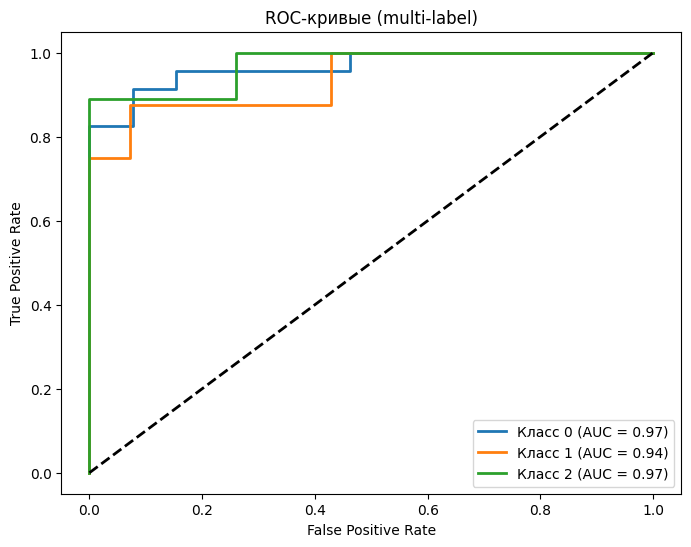

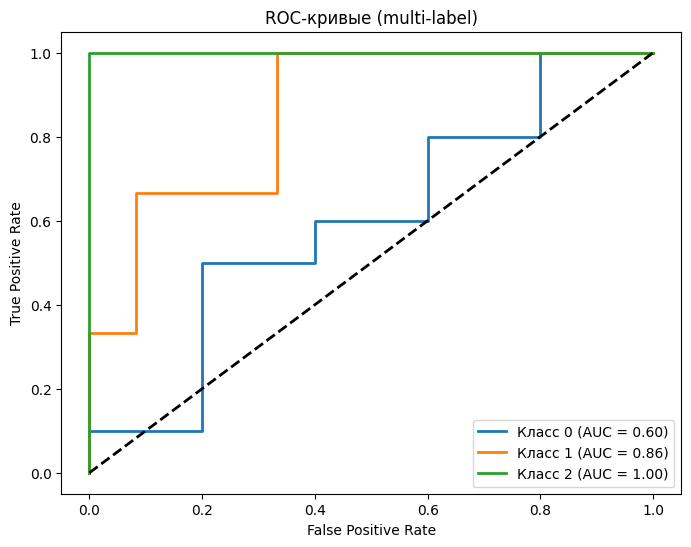

In [202]:
forest = model_training(forest, X_train=X_train_sbs, y_train=y_train, n_splits=20)
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(forest, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(forest, X_train_sbs, y_train, n_classes=3)
plot_roc_curve_multilabel(forest, X_test_sbs, y_test, n_classes=3)

In [204]:
import joblib

joblib.dump({
    'model': forest,
    'metadata': {
        'train_score': forest.score(X_train_sbs, y_train),
        'test_score': forest.score(X_test_sbs, y_test)
    }
}, 'model_and_metadata_kas_forest.pkl')

['model_and_metadata_kas_forest.pkl']

### AdaBoost

In [205]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=3)
ada  = OneVsRestClassifier(AdaBoostClassifier(estimator=tree, random_state=1))
param_grid_ada = {
    'estimator__n_estimators': [25, 50, 100, 150, 200, 250],
    'estimator__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 1.0],
    'estimator__estimator__max_depth': [1, 2, 3, 4, 5]
}

grid_search_for_model(ada, param_grid_ada, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 210 candidates, totalling 420 fits
0.6499999999999999
{'estimator__estimator__max_depth': 4, 'estimator__learning_rate': 0.01, 'estimator__n_estimators': 25}


In [45]:
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

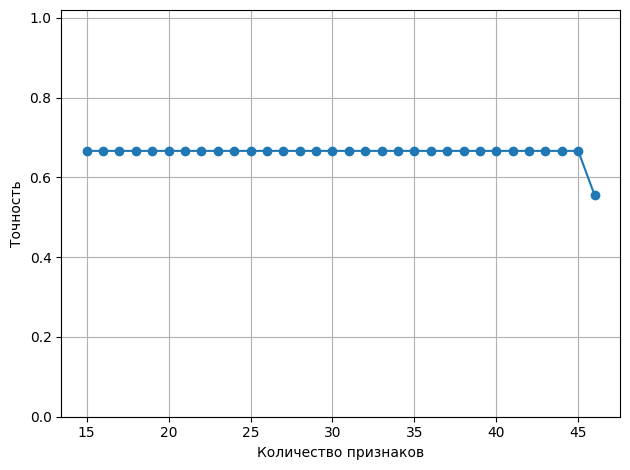

In [46]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=4), 
                         n_estimators=25, learning_rate=0.01, random_state=1)
sbs_ada = the_best_features(ada, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train_labels)

In [209]:
X_train_sbs, X_test_sbs = select_index_features(sbs_ada, index=4, X_train=X_train, X_test=X_test)

In [212]:
ada = model_training(ada, X_train=X_train_sbs, y_train=y_train_labels, n_splits=20)
data = {"Train": (X_train_sbs, y_train_labels),
        "Test": (X_test_sbs, y_test_labels)}
results = evaluate_model(ada, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(ada, X_train_sbs, y_train_labels, n_classes=3)
plot_roc_curve_multilabel(ada, X_test_sbs, y_test_labels, n_classes=3)

Fold 1: f1_macro = 0.000
Fold 2: f1_macro = 1.000
Fold 3: f1_macro = 0.333
Fold 4: f1_macro = 0.333
Fold 5: f1_macro = 0.333
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.333
Fold 8: f1_macro = 1.000
Fold 9: f1_macro = 0.000
Fold 10: f1_macro = 1.000
Fold 11: f1_macro = 0.333
Fold 12: f1_macro = 0.333
Fold 13: f1_macro = 1.000
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 1.000
Fold 16: f1_macro = 1.000
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 1.000
Fold 19: f1_macro = 0.000
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.450 (+/- 0.425)


IndexError: tuple index out of range

### XGBoost

In [44]:
param_grid_xgb = {
    'estimator__n_estimators': [100, 150, 200, 300],
    'estimator__max_depth': [3, 4, 5],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__subsample': [0.6, 0.8, 1.0],
    'estimator__colsample_bytree': [0.6, 0.8, 1.0],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__reg_alpha': [0, 0.1, 1],
    'estimator__reg_lambda': [1, 1.5, 2]
}
xgbm =  OneVsRestClassifier(xgb.XGBClassifier(random_state=1))
grid_search_for_model(xgbm, param_grid_xgb, X_train, y_train, cv=2, scoring='recall_weighted')

Fitting 2 folds for each of 11664 candidates, totalling 23328 fits
0.625
{'estimator__colsample_bytree': 0.6, 'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__min_child_weight': 1, 'estimator__n_estimators': 150, 'estimator__reg_alpha': 0, 'estimator__reg_lambda': 1.5, 'estimator__subsample': 1.0}


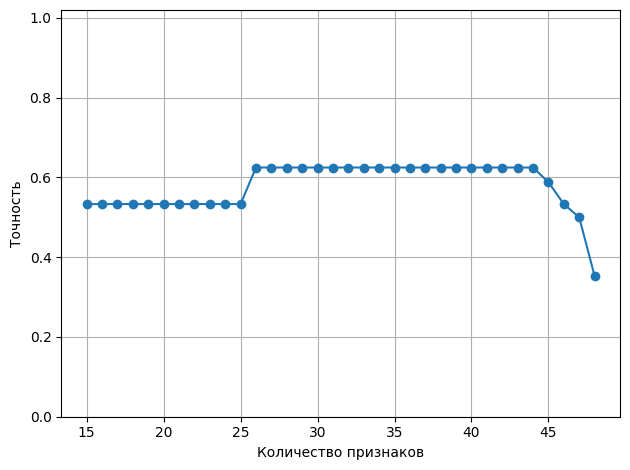

In [45]:
xgbm = OneVsRestClassifier(xgb.XGBClassifier(n_estimators=150, min_child_weight=1, max_depth=3, learning_rate=0.05, 
                                             colsample_bytree=0.6, reg_alpha=0,  reg_lambda=1.5, subsample=1.0, random_state=2))
sbs_xgbm = the_best_features(xgbm, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [46]:
X_train_sbs, X_test_sbs = select_index_features(sbs_xgbm, index=12, X_train=X_train, X_test=X_test)

In [47]:
xgbm = model_training(xgbm, X_train=X_train_sbs, y_train=y_train, n_splits=20)

Fold 1: f1_macro = 0.222
Fold 2: f1_macro = 0.333
Fold 3: f1_macro = 0.556
Fold 4: f1_macro = 0.222
Fold 5: f1_macro = 0.222
Fold 6: f1_macro = 0.000
Fold 7: f1_macro = 0.222
Fold 8: f1_macro = 0.667
Fold 9: f1_macro = 0.222
Fold 10: f1_macro = 0.222
Fold 11: f1_macro = 0.222
Fold 12: f1_macro = 0.556
Fold 13: f1_macro = 0.222
Fold 14: f1_macro = 0.000
Fold 15: f1_macro = 0.222
Fold 16: f1_macro = 0.222
Fold 17: f1_macro = 0.000
Fold 18: f1_macro = 0.667
Fold 19: f1_macro = 0.333
Fold 20: f1_macro = 0.000
Mean f1_macro: 0.267 (+/- 0.200)


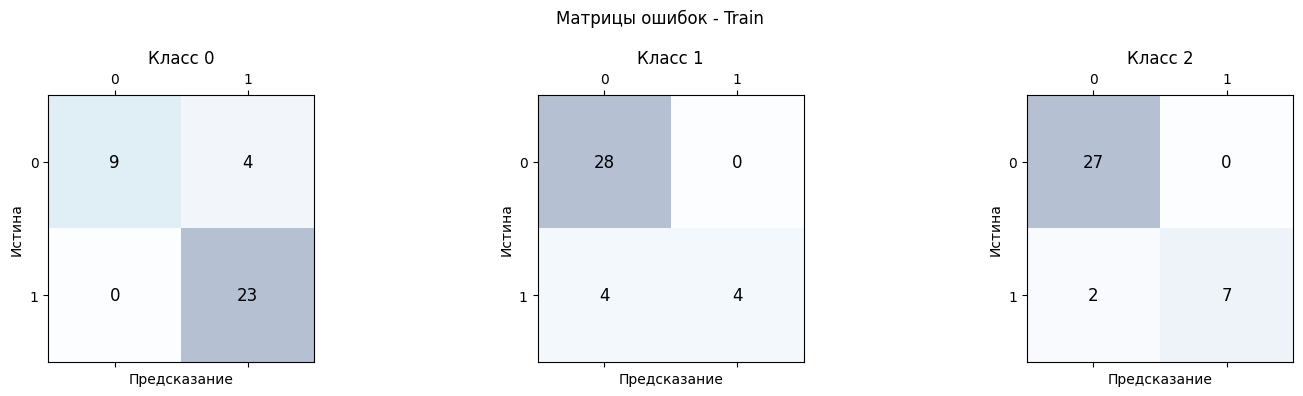

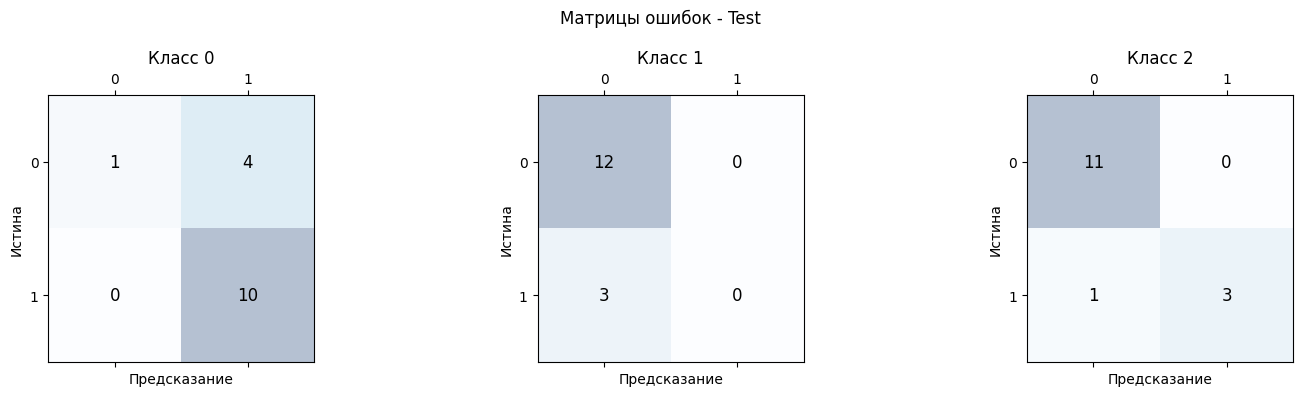

+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|  Dataset  |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |
+===========+============+========================+=====================+=====================+==================+=================+==============+
|   Train   |      0.806 |                  0.915 |               0.951 |               0.85  |            0.759 |           0.859 |        0.821 |
+-----------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+
|   Test    |      0.733 |                  0.655 |               0.571 |               0.765 |            0.583 |           0.692 |        0.563 |
+-----------+------------+------------------------+---------------------+---------------------+-----------------

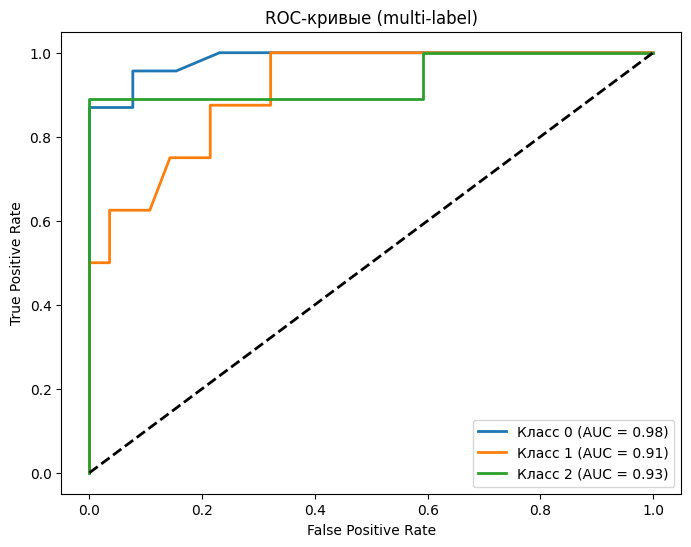

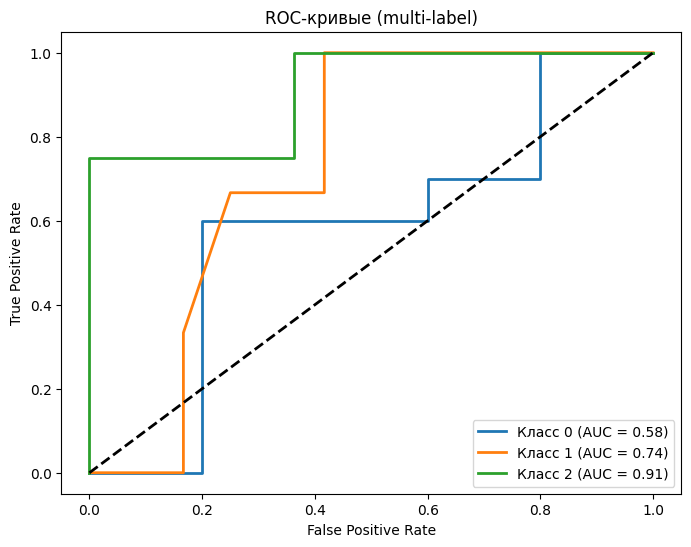

In [48]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evaluate_model(xgbm, data, metrics=['accuracy', 'precision', 'recall', 'f1'], average_methods=['weighted', 'macro'])
plot_roc_curve_multilabel(xgbm, X_train_sbs, y_train, n_classes=3)
plot_roc_curve_multilabel(xgbm, X_test_sbs, y_test, n_classes=3)

### MLP

In [50]:
X_val, y_val, X_test, y_test = iterative_train_test_split(
   X_test, y_test, test_size=0.5
)

In [52]:
param_grid_net = {
    'batch_size': [16, 32],
    'epochs': [30],
    'learning_rate': [0.001],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'elu'],
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'dropout_rate': [0.2],
    'use_batch_norm': [True],
    'l1_reg': [0.001],
    'l2_reg': [0.001]
}

best_score, best_params, all_results = manual_keras_grid_search(
    X_train, y_train, param_grid_net, cv=5
)

Всего комбинаций: 24

Комбинация 1/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer': 'adam', 'use_batch_norm': True}
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
  Fold 1: recall = 0.6667
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
  Fold 2: recall = 0.7143
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
  Fold 3: recall = 0.3750
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
  Fold 4: recall = 0.6250
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
  Fold 5: recall = 0.3750
  Средний recall: 0.5512

Комбинация 2/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer

In [63]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train.shape[1], )))


model.add(layers.Dense(32, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(16, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(8, 
                      activation='elu',
                      kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(3, activation='sigmoid'))

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train, y_train, epochs=40, batch_size=10, validation_data=(X_val, y_val))

Epoch 1/40
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4000 - loss: 0.7856 - precision: 0.4118 - recall: 0.6364
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.3600 - loss: 0.8621 - precision: 0.3746 - recall: 0.5205 - val_accuracy: 0.5714 - val_loss: 0.7166 - val_precision: 0.7500 - val_recall: 0.3750
Epoch 2/40
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4000 - loss: 0.7934 - precision: 0.3571 - recall: 0.4545
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3733 - loss: 0.8326 - precision: 0.3744 - recall: 0.4601 - val_accuracy: 0.5714 - val_loss: 0.7080 - val_precision: 0.8000 - val_recall: 0.5000
Epoch 3/40
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5000 - loss: 0.8502 - precision: 0.3333 - recall: 0.4545
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4233 - loss: 0.8279 - precision: 0.3492 - recall: 0.4536 - val_accuracy: 0.5714 - val_loss: 0.7019 - val_precision: 0.8000 - val_recall: 0.5000
Epoch 4/40
4
41/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

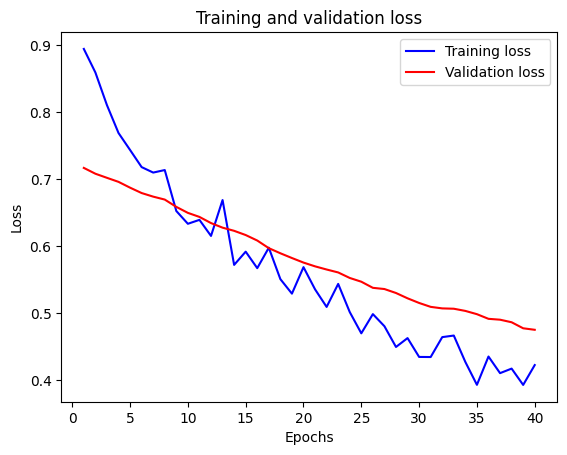

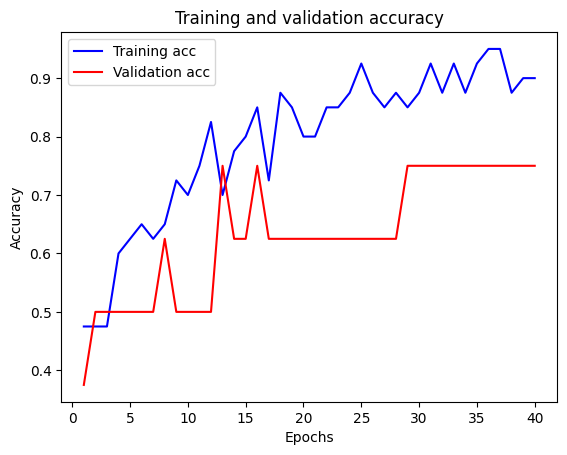

<Figure size 640x480 with 0 Axes>

In [64]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.clf()

In [65]:
data = {
            "Train": (X_train, y_train),
            "Validation": (X_val, y_val),
            "Test": (X_test, y_test)
        }

2
21/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
22/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


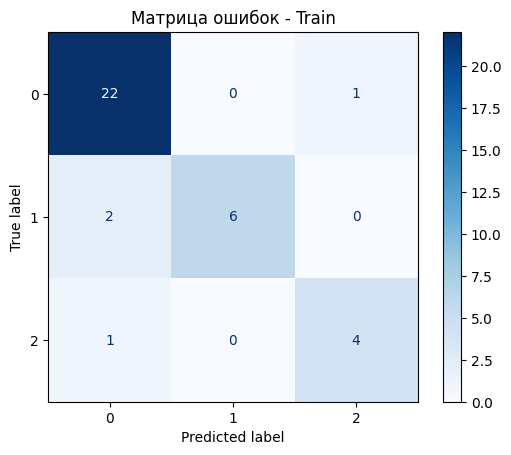

1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


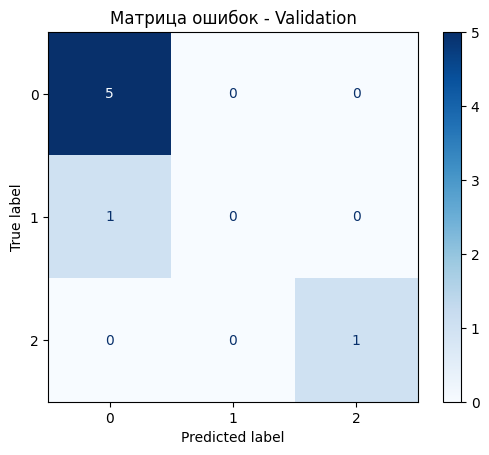

1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


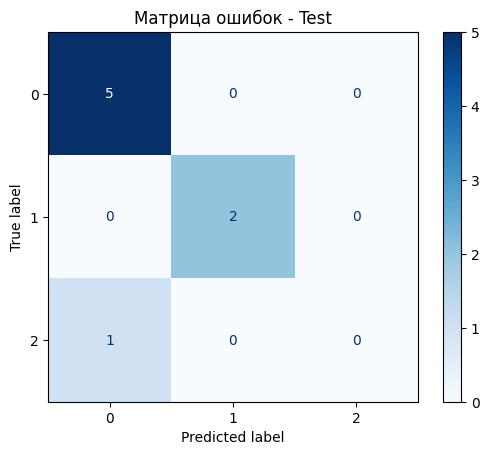

+------------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+------------------+---------------+
|  Dataset   |   Accuracy |   Precision (weighted) |   Precision (macro) |   Recall (weighted) |   Recall (macro) |   F1 (weighted) |   F1 (macro) |   Mcc (weighted) |   Mcc (macro) |
+============+============+========================+=====================+=====================+==================+=================+==============+==================+===============+
|   Train    |      0.889 |                  0.896 |               0.893 |               0.889 |            0.836 |           0.887 |        0.858 |                0 |             0 |
+------------+------------+------------------------+---------------------+---------------------+------------------+-----------------+--------------+------------------+---------------+
| Validation |      0.857 |                  0.738 |               0.611 |      

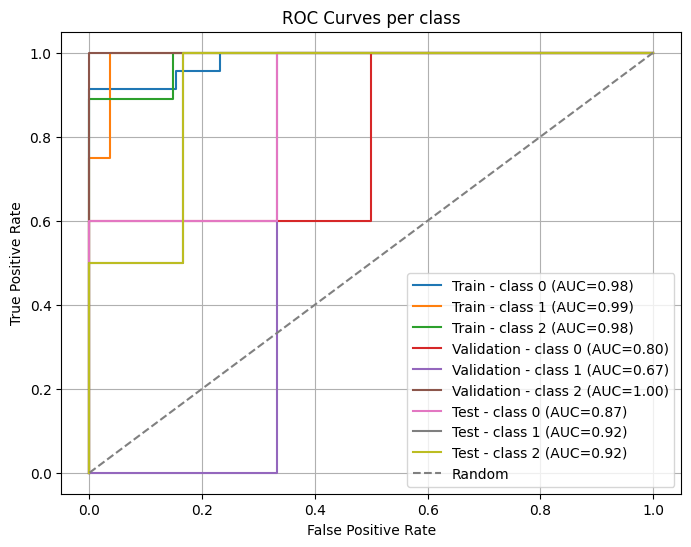

In [66]:
results = evaluate_model_for_keras(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['weighted', 'macro'])
ROC_curve_for_keras(data, model)

In [67]:
model.save('model_Kas_classification_recall_best_two.keras')